# This file is EDA on the datasets provided
It has been used to create graphs for both the report and presentation

In [4]:
# Import necessary librarys 
import pandas as pd
from datetime import timedelta
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [5]:
# Import file, look at shape, print head and clean NAs
forecastNSW = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/forecastdemand_nsw.csv")
print(forecastNSW.shape)
print(forecastNSW.head())
forecastNSW_clean = forecastNSW.dropna()
print(forecastNSW_clean.shape)
print(forecastNSW_clean.dtypes)

(10906019, 6)
   PREDISPATCHSEQNO REGIONID  PERIODID  FORECASTDEMAND          LASTCHANGED  \
0        2009123018     NSW1        71         7832.04  2009-12-30 12:31:49   
1        2009123019     NSW1        70         7832.04  2009-12-30 13:01:43   
2        2009123020     NSW1        69         7832.03  2009-12-30 13:31:36   
3        2009123021     NSW1        68         7832.03  2009-12-30 14:01:44   
4        2009123022     NSW1        67         7830.96  2009-12-30 14:31:35   

              DATETIME  
0  2010-01-01 00:00:00  
1  2010-01-01 00:00:00  
2  2010-01-01 00:00:00  
3  2010-01-01 00:00:00  
4  2010-01-01 00:00:00  
(10906019, 6)
PREDISPATCHSEQNO      int64
REGIONID             object
PERIODID              int64
FORECASTDEMAND      float64
LASTCHANGED          object
DATETIME             object
dtype: object


In [6]:
forecastNSW_clean.drop(['PREDISPATCHSEQNO', 'REGIONID'], axis=1, inplace=True)

In [7]:
# change date columns to date format
forecastNSW_clean['LASTCHANGED'] = pd.to_datetime(forecastNSW_clean['LASTCHANGED'])
forecastNSW_clean['DATETIME'] = pd.to_datetime(forecastNSW_clean['DATETIME'])
print(forecastNSW_clean.dtypes)

PERIODID                   int64
FORECASTDEMAND           float64
LASTCHANGED       datetime64[ns]
DATETIME          datetime64[ns]
dtype: object


Next is to add a column that looks at the difference between last change and date time to show the forecast period

In [8]:
# Created copy
forecastNSW_clean_rounded = forecastNSW_clean.copy()

# Function to round to the nearest 30 minutes
def round_to_nearest_half_hour(dt):
    minutes = dt.minute
    if minutes < 15:
        return dt.replace(minute=0, second=0, microsecond=0)
    elif minutes < 45:
        return dt.replace(minute=30, second=0, microsecond=0)
    else:
        return (dt + pd.Timedelta(hours=1)).replace(minute=0, second=0, microsecond=0)

# Apply the rounding function to the 'DATETIME' column
forecastNSW_clean_rounded['LASTCHANGED_ROUNDED'] = forecastNSW_clean_rounded['LASTCHANGED'].apply(round_to_nearest_half_hour)
#forecastNSW_clean['DATETIME_ROUNDED'] = forecastNSW_clean['DATETIME'].apply(round_to_nearest_half_hour)

# Calculate the difference in seconds between rounded 'DATETIME' and 'LASTCHANGED'
time_diff = (forecastNSW_clean_rounded['DATETIME'] - forecastNSW_clean_rounded['LASTCHANGED_ROUNDED']).dt.total_seconds()

# Create the new 'time_dhms' column with formatted strings (accounting for days)
forecastNSW_clean_rounded['time_dhms'] = time_diff.apply(lambda x: "{:d} days {:02d}:{:02d}:{:02d}".format(
    int(x // (24 * 3600)),  # Days
    int((x % (24 * 3600)) // 3600),  # Hours
    int((x % 3600) // 60),  # Minutes
    int(x % 60)  # Seconds
))

# Sorting the DataFrame by 'PERIODID' in descending order
forecastNSW_clean_rounded = forecastNSW_clean_rounded.sort_values(by='PERIODID', ascending=False)

# Display the first few rows of the sorted DataFrame
print(forecastNSW_clean_rounded[['DATETIME', 'LASTCHANGED', 'LASTCHANGED_ROUNDED', 'time_dhms']].head())
print(forecastNSW_clean_rounded.dtypes)

                   DATETIME         LASTCHANGED LASTCHANGED_ROUNDED  \
8599714 2018-11-03 04:00:00 2018-11-01 12:31:55 2018-11-01 12:30:00   
8719521 2018-12-18 04:00:00 2018-12-16 12:31:39 2018-12-16 12:30:00   
8341306 2018-07-29 04:00:00 2018-07-27 12:31:46 2018-07-27 12:30:00   
2763235 2012-11-03 04:00:00 2012-11-01 12:31:46 2012-11-01 12:30:00   
67196   2010-01-26 04:00:00 2010-01-24 12:31:53 2010-01-24 12:30:00   

               time_dhms  
8599714  1 days 15:30:00  
8719521  1 days 15:30:00  
8341306  1 days 15:30:00  
2763235  1 days 15:30:00  
67196    1 days 15:30:00  
PERIODID                        int64
FORECASTDEMAND                float64
LASTCHANGED            datetime64[ns]
DATETIME               datetime64[ns]
LASTCHANGED_ROUNDED    datetime64[ns]
time_dhms                      object
dtype: object


In [9]:
# Drop duplicates method
lagtimes = forecastNSW_clean_rounded[['PERIODID', 'time_dhms']].drop_duplicates(subset='PERIODID')
print(lagtimes)

          PERIODID        time_dhms
8599714         79  1 days 15:30:00
823773          78  1 days 15:00:00
10869171        77  1 days 14:30:00
6063964         76  1 days 14:00:00
2693975         75  1 days 13:30:00
...            ...              ...
10260923         5  0 days 02:30:00
3488800          4  0 days 02:00:00
3461773          3  0 days 01:30:00
642762           2  0 days 01:00:00
10880014         1  0 days 00:30:00

[79 rows x 2 columns]


In [10]:
# Group by and aggregate method. Unable to average on the time column
df_periodid_time = forecastNSW_clean_rounded[['PERIODID', 'time_dhms']]
df_periodid = df_periodid_time.groupby('PERIODID').agg({
    'time_dhms': 'first'  # Example: you can use 'first', 'max', 'min', or any other aggregation function
})
print(df_periodid)

                time_dhms
PERIODID                 
1         0 days 00:30:00
2         0 days 01:00:00
3         0 days 01:30:00
4         0 days 02:00:00
5         0 days 02:30:00
...                   ...
75        1 days 13:30:00
76        1 days 14:00:00
77        1 days 14:30:00
78        1 days 15:00:00
79        1 days 15:30:00

[79 rows x 1 columns]


In [11]:
value_counts = forecastNSW_clean_rounded['PERIODID'].value_counts()
print(value_counts)
max_value = forecastNSW_clean_rounded['DATETIME'].max()
min_value = forecastNSW_clean_rounded['DATETIME'].min()

(max_value-min_value)

PERIODID
1     196505
17    196505
32    196505
31    196505
30    196505
       ...  
75     20467
76     16373
77     12279
78      8187
79      4094
Name: count, Length: 79, dtype: int64


Timedelta('4094 days 00:00:00')

In [12]:
datespan = 4094*48
print(f"The amount of half hour periods over the dataspan is {datespan}")

The amount of half hour periods over the dataspan is 196512


Period ID 1 is a half hour ahead forecast, as the period ID increases by 1 so does the half hour period. This goes all the way up to the further forecasts in the dateset at period ID 79 ~ 1 day and 15.5hrs ahead. As the period ID increases the number of observations over the dataset decreases.

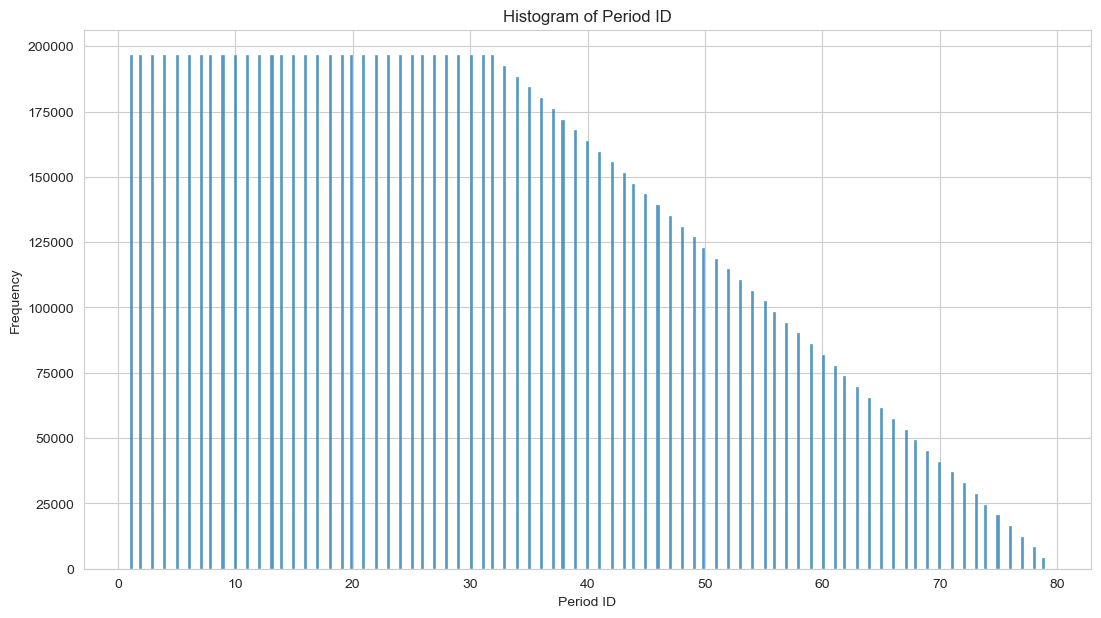

In [47]:
# Histogram of Period ID
plt.figure(figsize=(13, 7))
sns.histplot(forecastNSW_clean_rounded['PERIODID'], kde=False)
plt.xlabel('Period ID')
plt.ylabel('Frequency')
plt.title('Histogram of Period ID')
plt.show()

This histogram shows that the shorter forecasts were the most common. Period IDs 1 to 32 were used to forecast every half hour period in the dataset. Higher period ID were forecast less often at a diminishing rate. This shows that the creater of the dataset were most interested in forecasts up to 16 hours ahead.

In [14]:
# Import demand data
demandNSW = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/totaldemand_nsw.csv")
print(demandNSW.shape)
print(demandNSW.head())
demandNSW_clean = demandNSW.dropna()
demandNSW_clean['DATETIME'] = pd.to_datetime(demandNSW_clean['DATETIME'], format='%d/%m/%Y %H:%M')

print(demandNSW_clean.shape)
print(demandNSW_clean.dtypes)
print(demandNSW_clean.describe())

(196513, 3)
        DATETIME  TOTALDEMAND REGIONID
0  1/1/2010 0:00      8038.00     NSW1
1  1/1/2010 0:30      7809.31     NSW1
2  1/1/2010 1:00      7483.69     NSW1
3  1/1/2010 1:30      7117.23     NSW1
4  1/1/2010 2:00      6812.03     NSW1
(196513, 3)
DATETIME       datetime64[ns]
TOTALDEMAND           float64
REGIONID               object
dtype: object
                            DATETIME    TOTALDEMAND
count                         196513  196513.000000
mean   2015-08-10 00:00:00.000000512    8113.145859
min              2010-01-01 00:00:00    5074.630000
25%              2012-10-20 12:00:00    7150.070000
50%              2015-08-10 00:00:00    8053.230000
75%              2018-05-29 12:00:00    8958.550000
max              2021-03-18 00:00:00   14579.860000
std                              NaN    1299.532774


In [15]:
demandNSW_diff = demandNSW_clean.copy()
demandNSW_diff['Time_Difference'] = demandNSW_diff['DATETIME'] - demandNSW_diff['DATETIME'].shift(1)
print(demandNSW_diff.describe())
print(f"The amount of half hour periods over the dataspan is {datespan}")

                            DATETIME    TOTALDEMAND  Time_Difference
count                         196513  196513.000000           196512
mean   2015-08-10 00:00:00.000000512    8113.145859  0 days 00:30:00
min              2010-01-01 00:00:00    5074.630000  0 days 00:30:00
25%              2012-10-20 12:00:00    7150.070000  0 days 00:30:00
50%              2015-08-10 00:00:00    8053.230000  0 days 00:30:00
75%              2018-05-29 12:00:00    8958.550000  0 days 00:30:00
max              2021-03-18 00:00:00   14579.860000  0 days 00:30:00
std                              NaN    1299.532774  0 days 00:00:00
The amount of half hour periods over the dataspan is 196512


The demand data doesn't have any missing time periods over the datespan

In [16]:
# Merge forecast and demand data
forecast_demand_NSW= pd.merge(forecastNSW_clean, demandNSW_clean, 
                              how='left', on='DATETIME')

forecast_demand_NSW['FORECASTERRORABS'] = abs(forecast_demand_NSW['FORECASTDEMAND'] - forecast_demand_NSW['TOTALDEMAND'])
forecast_demand_NSW['FORECASTERROR2'] = pow((forecast_demand_NSW['FORECASTDEMAND'] - forecast_demand_NSW['TOTALDEMAND']),2)
print(forecast_demand_NSW.head())
print(forecast_demand_NSW.describe())
print(forecast_demand_NSW.shape)
forecast_demand_NSW

   PERIODID  FORECASTDEMAND         LASTCHANGED   DATETIME  TOTALDEMAND  \
0        71         7832.04 2009-12-30 12:31:49 2010-01-01       8038.0   
1        70         7832.04 2009-12-30 13:01:43 2010-01-01       8038.0   
2        69         7832.03 2009-12-30 13:31:36 2010-01-01       8038.0   
3        68         7832.03 2009-12-30 14:01:44 2010-01-01       8038.0   
4        67         7830.96 2009-12-30 14:31:35 2010-01-01       8038.0   

  REGIONID  FORECASTERRORABS  FORECASTERROR2  
0     NSW1            205.96      42419.5216  
1     NSW1            205.96      42419.5216  
2     NSW1            205.97      42423.6409  
3     NSW1            205.97      42423.6409  
4     NSW1            207.04      42865.5616  
           PERIODID  FORECASTDEMAND                    LASTCHANGED  \
count  1.090602e+07    1.090602e+07                       10906019   
mean   2.997893e+01    8.066719e+03  2015-08-09 07:21:49.039252224   
min    1.000000e+00    4.422460e+03            2009-12-30

,PERIODID,FORECASTDEMAND,LASTCHANGED,DATETIME,TOTALDEMAND,REGIONID,FORECASTERRORABS,FORECASTERROR2
0,71,7832.04,2009-12-30 12:31:49,2010-01-01,8038.00,NSW1,205.96,42419.5216
1,70,7832.04,2009-12-30 13:01:43,2010-01-01,8038.00,NSW1,205.96,42419.5216
2,69,7832.03,2009-12-30 13:31:36,2010-01-01,8038.00,NSW1,205.97,42423.6409
3,68,7832.03,2009-12-30 14:01:44,2010-01-01,8038.00,NSW1,205.97,42423.6409
4,67,7830.96,2009-12-30 14:31:35,2010-01-01,8038.00,NSW1,207.04,42865.5616
...,...,...,...,...,...,...,...,...
10906014,5,7028.45,2021-03-17 21:31:31,2021-03-18,7094.51,NSW1,66.06,4363.9236
10906015,4,7041.65,2021-03-17 22:01:34,2021-03-18,7094.51,NSW1,52.86,2794.1796
10906016,3,7087.60,2021-03-17 22:31:36,2021-03-18,7094.51,NSW1,6.91,47.7481
10906017,2,7087.28,2021-03-17 23:01:36,2021-03-18,7094.51,NSW1,7.23,52.2729


In [17]:
# Calculate the performance of the forecast dataset against demand
period_error = forecast_demand_NSW.groupby('PERIODID').agg(
    mae=pd.NamedAgg(column='FORECASTERRORABS', aggfunc='mean'),
    mse=pd.NamedAgg(column='FORECASTERROR2', aggfunc='mean')
).reset_index()

In [18]:
# Sort the DataFrame by mae decending to find the period ID with the most inaccurate forecast
period_error_sorted = period_error.sort_values(by='mse', ascending=False)
print(period_error_sorted.head())

    PERIODID         mae           mse
45        46  184.286623  66672.856748
46        47  183.930692  66625.735719
44        45  184.499705  66598.017097
47        48  183.347363  66404.757797
43        44  184.463259  66355.683121


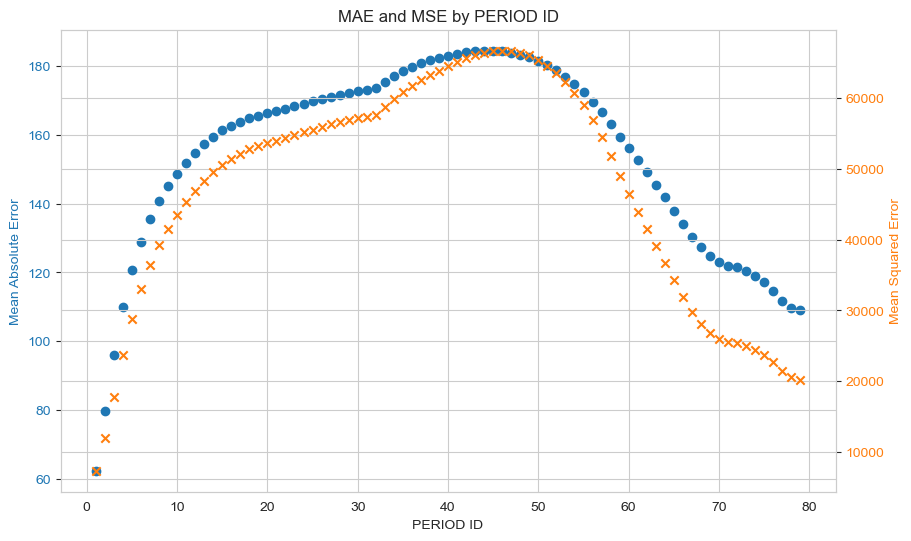

In [89]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Scatter of MAE
ax1.set_xlabel('PERIOD ID')
ax1.set_ylabel('Mean Absolute Error', color='tab:blue')
ax1.scatter(period_error_sorted['PERIODID'], period_error_sorted['mae'], marker='o', color='tab:blue', label='Mean Absolute Error')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Scatter of MSE
ax2 = ax1.twinx() 
ax2.set_ylabel('Mean Squared Error', color='tab:orange')
ax2.scatter(period_error_sorted['PERIODID'], period_error_sorted['mse'], marker='x', color='tab:orange', label='Mean Squared Error')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.xticks(rotation=90)
plt.title('MAE and MSE by PERIOD ID')

plt.show()

In [76]:
from sklearn.model_selection import train_test_split
actual_train, actual_test = train_test_split(forecast_demand_NSW, train_size=0.8, shuffle=False)

In [78]:
# Calculate the performance of the forecast dataset against demand
period_error_test = actual_test.groupby('PERIODID').agg(
    mae=pd.NamedAgg(column='FORECASTERRORABS', aggfunc='mean'),
    mse=pd.NamedAgg(column='FORECASTERROR2', aggfunc='mean')
).reset_index()

In [84]:
# Sort the DataFrame by mae decending to find the period ID with the most inaccurate forecast
period_error_test_sorted = period_error_test.sort_values(by='mse', ascending=True)
print(period_error_test_sorted.head())

    PERIODID         mae           mse
0          1   50.902736   4736.809065
1          2   74.861469  10713.485705
78        79  101.300134  17352.761901
77        78  102.635736  18529.824661
2          3   98.070956  19485.707268


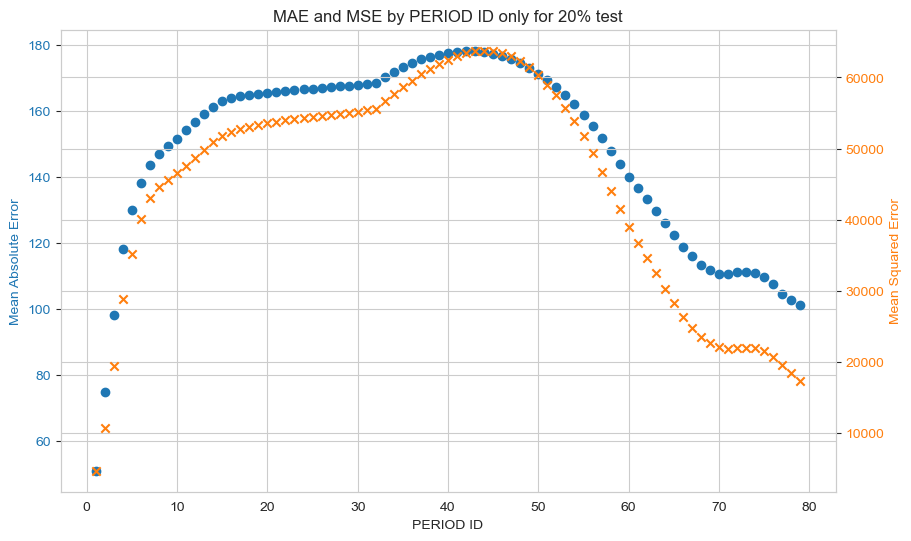

In [91]:
fig, ax3 = plt.subplots(figsize=(10, 6))

# Scatter of MAE
ax3.set_xlabel('PERIOD ID')
ax3.set_ylabel('Mean Absolute Error', color='tab:blue')
ax3.scatter(period_error_test_sorted['PERIODID'], period_error_test_sorted['mae'], marker='o', color='tab:blue', label='Mean Absolute Error')
ax3.tick_params(axis='y', labelcolor='tab:blue')

# Scatter of MSE
ax4 = ax3.twinx() 
ax4.set_ylabel('Mean Squared Error', color='tab:orange')
ax4.scatter(period_error_test_sorted['PERIODID'], period_error_test_sorted['mse'], marker='x', color='tab:orange', label='Mean Squared Error')
ax4.tick_params(axis='y', labelcolor='tab:orange')

plt.xticks(rotation=90)
plt.title('MAE and MSE by PERIOD ID only for 20% test')

plt.show()

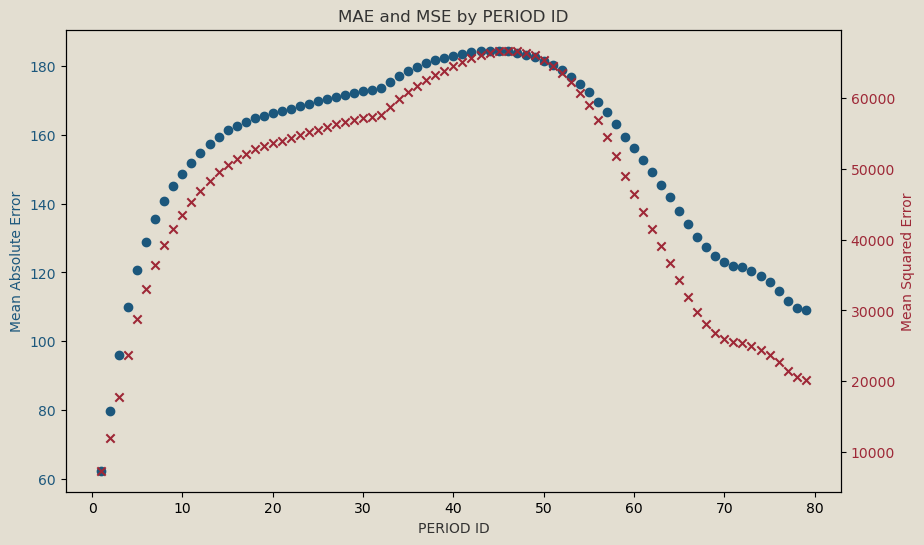

In [20]:
# Different colour scheme
fig, ax1 = plt.subplots(figsize=(10, 6))

# Scatter of MAE
ax1.set_xlabel('PERIOD ID', color='#333332')
ax1.set_ylabel('Mean Absolute Error', color='#1c577c')
ax1.scatter(period_error_sorted['PERIODID'], period_error_sorted['mae'], marker='o', color='#1c577c', label='Mean Absolute Error')
ax1.tick_params(axis='y', labelcolor='#1c577c')

# Scatter of MSE
ax2 = ax1.twinx() 
ax2.set_ylabel('Mean Squared Error', color='#9e2837')
ax2.scatter(period_error_sorted['PERIODID'], period_error_sorted['mse'], marker='x', color='#9e2837', label='Mean Squared Error')
ax2.tick_params(axis='y', labelcolor='#9e2837')

plt.xticks(rotation=90, color='#333332')
plt.title('MAE and MSE by PERIOD ID', color='#333332')
fig.patch.set_facecolor('#e3ded1')
ax1.set_facecolor('#e3ded1')
plt.show()

In [21]:
period_error_sorted_lag= pd.merge(period_error_sorted, lagtimes, 
                              how='left', on='PERIODID')

print(period_error_sorted_lag)

    PERIODID         mae           mse        time_dhms
0         46  184.286623  66672.856748  0 days 23:00:00
1         47  183.930692  66625.735719  0 days 23:30:00
2         45  184.499705  66598.017097  0 days 22:30:00
3         48  183.347363  66404.757797  1 days 00:00:00
4         44  184.463259  66355.683121  0 days 22:00:00
..       ...         ...           ...              ...
74        78  109.748935  20600.194904  1 days 15:00:00
75        79  109.004384  20149.064779  1 days 15:30:00
76         3   95.905777  17808.672118  0 days 01:30:00
77         2   79.694136  12059.919061  0 days 01:00:00
78         1   62.324479   7370.348981  0 days 00:30:00

[79 rows x 4 columns]


Surprisingly, the most inaccurate forecast wasn't the one furthest into the future but around the 22 hours ahead. Forecasts around period ID 45 were not for every time period in the dataspan but did cover 70% of them. It might be worthwhile investigating this period ID further.

In [22]:
# Import public holiday data and use on demandNSW_clean
import holidays
nsw_holidays = holidays.Australia(state='NSW', years=range(2010, 2022))

# Display the NSW holidays for the specified years
for date, name in sorted(nsw_holidays.items()):
    print(f"{date}: {name}")

2010-01-01: New Year's Day
2010-01-26: Australia Day
2010-04-02: Good Friday
2010-04-03: Easter Saturday
2010-04-05: Easter Monday
2010-04-25: ANZAC Day
2010-04-26: ANZAC Day (observed)
2010-06-14: Queen's Birthday
2010-08-02: Bank Holiday
2010-10-04: Labour Day
2010-12-25: Christmas Day
2010-12-26: Boxing Day
2010-12-27: Boxing Day (observed)
2011-01-01: New Year's Day
2011-01-03: New Year's Day (observed)
2011-01-26: Australia Day
2011-04-22: Good Friday
2011-04-23: Easter Saturday
2011-04-24: Easter Sunday
2011-04-25: ANZAC Day; Easter Monday
2011-06-13: Queen's Birthday
2011-10-03: Labour Day
2011-12-25: Christmas Day
2011-12-26: Boxing Day
2011-12-27: Christmas Day (observed)
2012-01-01: New Year's Day
2012-01-02: New Year's Day (observed)
2012-01-26: Australia Day
2012-04-06: Good Friday
2012-04-07: Easter Saturday
2012-04-08: Easter Sunday
2012-04-09: Easter Monday
2012-04-25: ANZAC Day
2012-06-11: Queen's Birthday
2012-10-01: Labour Day
2012-12-25: Christmas Day
2012-12-26: Box

In [23]:
demandNSW_clean['Holidays'] = demandNSW_clean.DATETIME.apply(lambda date: nsw_holidays.get(date))

demandNSW_clean.holidays = demandNSW_clean.Holidays.fillna(0) 
print(demandNSW_clean.head())
demandNSW_clean.Holidays.unique()

             DATETIME  TOTALDEMAND REGIONID        Holidays
0 2010-01-01 00:00:00      8038.00     NSW1  New Year's Day
1 2010-01-01 00:30:00      7809.31     NSW1  New Year's Day
2 2010-01-01 01:00:00      7483.69     NSW1  New Year's Day
3 2010-01-01 01:30:00      7117.23     NSW1  New Year's Day
4 2010-01-01 02:00:00      6812.03     NSW1  New Year's Day


/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/247483218.py:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  demandNSW_clean.holidays = demandNSW_clean.Holidays.fillna(0)


array(["New Year's Day", None, 'Australia Day', 'Good Friday',
       'Easter Saturday', 'Easter Monday', 'ANZAC Day',
       'ANZAC Day (observed)', "Queen's Birthday", 'Bank Holiday',
       'Labour Day', 'Christmas Day', 'Boxing Day',
       'Boxing Day (observed)', "New Year's Day (observed)",
       'Easter Sunday', 'ANZAC Day; Easter Monday',
       'Christmas Day (observed)'], dtype=object)

In [24]:
mapping = {"New Year's Day" : 1,
           'None' : 0,
           'NaN' : 0,
           'Australia Day' : 1,
           'Good Friday' : 1,
           'Easter Saturday' : 1,
           'Easter Monday' : 1,
           'ANZAC Day' : 1,
           'ANZAC Day (observed)' : 1,
           "Queen's Birthday" : 1,
           'Labour Day' : 1,
           'Christmas Day' : 1,
           'Boxing Day' : 1,
           'Boxing Day (observed)' : 1 ,
           "New Year's Day (observed)" : 1,
           'Easter Sunday' : 1, 
           'ANZAC Day; Easter Monday' : 1,
           'Christmas Day (observed)' : 1,
           'Bank Holiday' : 0
          }

demandNSW_clean = demandNSW_clean.replace({'Holidays': mapping})

demandNSW_clean['Holidays'].fillna(0, inplace=True)
demandNSW_clean.Holidays.unique()


/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/3268205495.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  demandNSW_clean = demandNSW_clean.replace({'Holidays': mapping})
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/3268205495.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the 

array([1., 0.])

In [25]:
demandNSW_clean['DATETIME'] = pd.to_datetime(demandNSW_clean['DATETIME'])
demandNSW_clean['Weekday'] = demandNSW_clean['DATETIME'].dt.dayofweek
print(demandNSW_clean)
print(demandNSW_clean.dtypes)

                  DATETIME  TOTALDEMAND REGIONID  Holidays  Weekday
0      2010-01-01 00:00:00      8038.00     NSW1       1.0        4
1      2010-01-01 00:30:00      7809.31     NSW1       1.0        4
2      2010-01-01 01:00:00      7483.69     NSW1       1.0        4
3      2010-01-01 01:30:00      7117.23     NSW1       1.0        4
4      2010-01-01 02:00:00      6812.03     NSW1       1.0        4
...                    ...          ...      ...       ...      ...
196508 2021-03-17 22:00:00      7419.77     NSW1       0.0        2
196509 2021-03-17 22:30:00      7417.91     NSW1       0.0        2
196510 2021-03-17 23:00:00      7287.32     NSW1       0.0        2
196511 2021-03-17 23:30:00      7172.39     NSW1       0.0        2
196512 2021-03-18 00:00:00      7094.51     NSW1       0.0        3

[196513 rows x 5 columns]
DATETIME       datetime64[ns]
TOTALDEMAND           float64
REGIONID               object
Holidays              float64
Weekday                 int32
dtype: 

/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/946081251.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(x = 'Holidays', y = 'TOTALDEMAND', data = demandNSW_clean, palette=colors)
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/946081251.py:6: UserWarning: The palette list has more values (7) than needed (2), which may not be intended.
  g = sns.boxplot(x = 'Holidays', y = 'TOTALDEMAND', data = demandNSW_clean, palette=colors)
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/946081251.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(hol_labels)


[Text(0, 0, 'Non-holiday'), Text(1, 0, 'Holiday')]

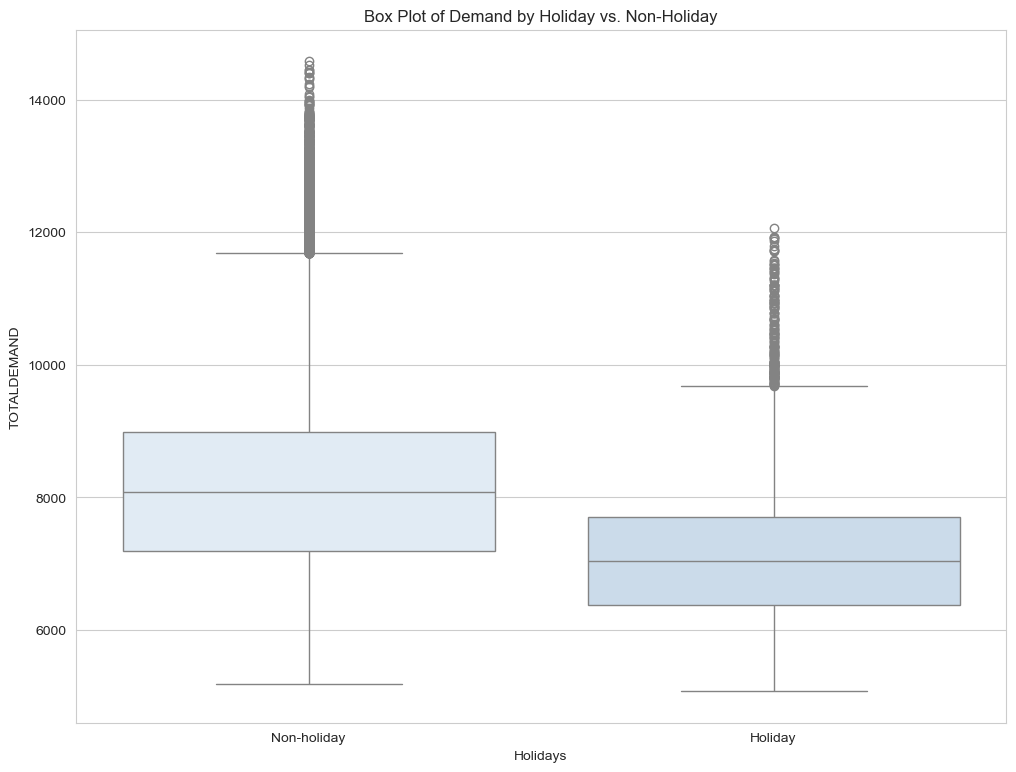

In [70]:
sns.set_style("whitegrid")
colors = sns.color_palette("Blues", len(week_labels))
plt.rcParams['figure.figsize'] = (12,9)

hol_labels = ['Non-holiday', 'Holiday']
g = sns.boxplot(x = 'Holidays', y = 'TOTALDEMAND', data = demandNSW_clean, palette=colors)
g.set_title('Box Plot of Demand by Holiday vs. Non-Holiday')
g.set_xticklabels(hol_labels)

/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/533677665.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(x = 'Weekday', y = 'TOTALDEMAND', data = demandNSW_clean, palette=colors)
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/533677665.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(week_labels)


[Text(0, 0, 'Monday'),
 Text(1, 0, 'Tuesday'),
 Text(2, 0, 'Wednesday'),
 Text(3, 0, 'Thursday'),
 Text(4, 0, 'Friday'),
 Text(5, 0, 'Saturday'),
 Text(6, 0, 'Sunday')]

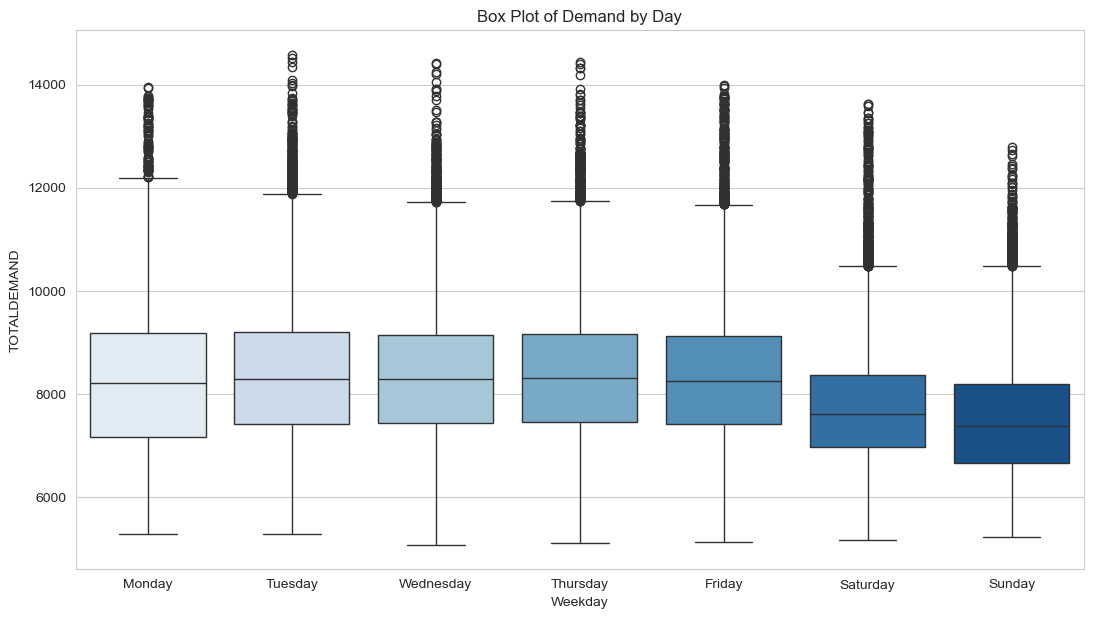

In [71]:
plt.rcParams['figure.figsize'] = (13,7)
week_labels = ['Monday', 'Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
g = sns.boxplot(x = 'Weekday', y = 'TOTALDEMAND', data = demandNSW_clean, palette=colors)
g.set_title('Box Plot of Demand by Day')
g.set_xticklabels(week_labels)

In [29]:
# Seperate out holidays
demandNSW_clean['Days/Holidays'] = demandNSW_clean.apply(
    lambda row: 7 if row['Holidays'] == 1 else row['Weekday'], axis=1
)
print(demandNSW_clean)

                  DATETIME  TOTALDEMAND REGIONID  Holidays  Weekday  \
0      2010-01-01 00:00:00      8038.00     NSW1       1.0        4   
1      2010-01-01 00:30:00      7809.31     NSW1       1.0        4   
2      2010-01-01 01:00:00      7483.69     NSW1       1.0        4   
3      2010-01-01 01:30:00      7117.23     NSW1       1.0        4   
4      2010-01-01 02:00:00      6812.03     NSW1       1.0        4   
...                    ...          ...      ...       ...      ...   
196508 2021-03-17 22:00:00      7419.77     NSW1       0.0        2   
196509 2021-03-17 22:30:00      7417.91     NSW1       0.0        2   
196510 2021-03-17 23:00:00      7287.32     NSW1       0.0        2   
196511 2021-03-17 23:30:00      7172.39     NSW1       0.0        2   
196512 2021-03-18 00:00:00      7094.51     NSW1       0.0        3   

        Days/Holidays  
0                   7  
1                   7  
2                   7  
3                   7  
4                   7  
...

/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/2230989261.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(x='Days/Holidays', y='TOTALDEMAND', data=demandNSW_clean, palette=colors)
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/2230989261.py:3: UserWarning: 
The palette list has fewer values (7) than needed (8) and will cycle, which may produce an uninterpretable plot.
  g = sns.boxplot(x='Days/Holidays', y='TOTALDEMAND', data=demandNSW_clean, palette=colors)
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/2230989261.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(week_labels2)


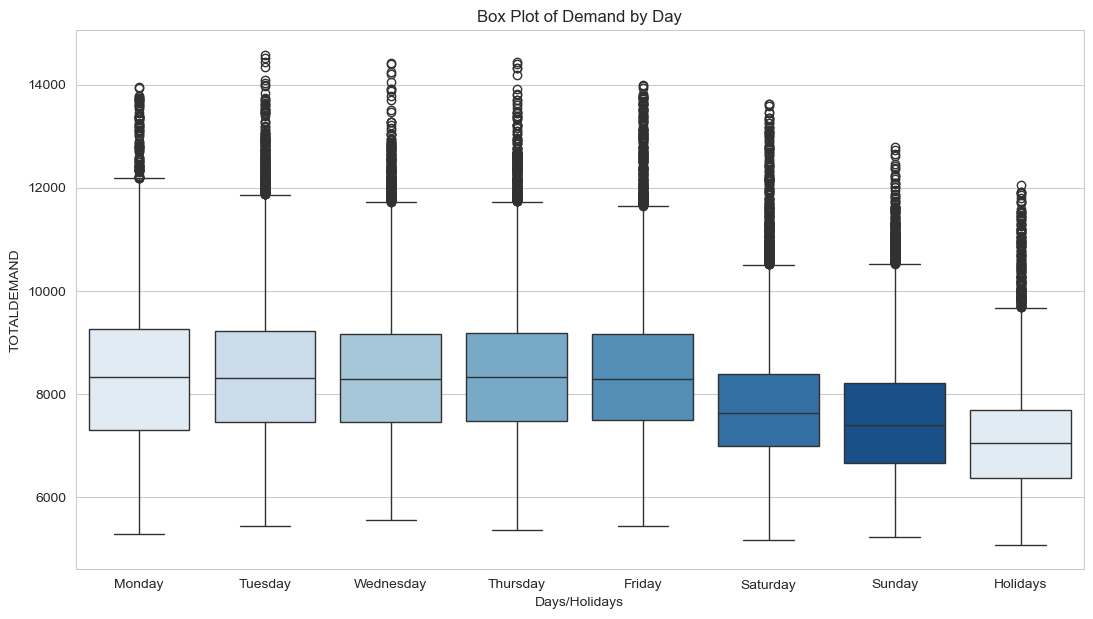

In [45]:
week_labels2 = ['Monday', 'Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday', 'Holidays']
plt.figure(figsize=(13, 7))
g = sns.boxplot(x='Days/Holidays', y='TOTALDEMAND', data=demandNSW_clean, palette=colors)
g.set(title='Box Plot of Demand by Day')
g.set_xticklabels(week_labels2)

plt.show()

The box plots above show that there is an electricity demand decrease when there is a public holiday. It is closest to Sunday but there is a similar decrease in demand from Saturday to Sunday as there is from Sunday to Holiday so it might be worthwhile keeping it seperate for analysis.

In [31]:
# Add in datetime based fields
demandNSW_clean['Hour'] = demandNSW_clean.DATETIME.dt.hour
demandNSW_clean['Minute'] = demandNSW_clean.DATETIME.dt.minute
demandNSW_clean['Time'] = (demandNSW_clean.Hour * 60 + demandNSW_clean.Minute) / 60
demandNSW_clean['Month'] = demandNSW_clean.DATETIME.dt.month
demandNSW_clean['Year'] = demandNSW_clean.DATETIME.dt.year
demandNSW_clean.head()

,DATETIME,TOTALDEMAND,REGIONID,Holidays,Weekday,Days/Holidays,Hour,Minute,Time,Month,Year
0,2010-01-01 00:00:00,8038.00,NSW1,1.0,4,7,0,0,0.0,1,2010
1,2010-01-01 00:30:00,7809.31,NSW1,1.0,4,7,0,30,0.5,1,2010
2,2010-01-01 01:00:00,7483.69,NSW1,1.0,4,7,1,0,1.0,1,2010
3,2010-01-01 01:30:00,7117.23,NSW1,1.0,4,7,1,30,1.5,1,2010
4,2010-01-01 02:00:00,6812.03,NSW1,1.0,4,7,2,0,2.0,1,2010


In [32]:
# add in season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else:
        return 'Spring'

demandNSW_clean['Season'] = demandNSW_clean['DATETIME'].dt.month.apply(get_season)
print(demandNSW_clean)
    

                  DATETIME  TOTALDEMAND REGIONID  Holidays  Weekday  \
0      2010-01-01 00:00:00      8038.00     NSW1       1.0        4   
1      2010-01-01 00:30:00      7809.31     NSW1       1.0        4   
2      2010-01-01 01:00:00      7483.69     NSW1       1.0        4   
3      2010-01-01 01:30:00      7117.23     NSW1       1.0        4   
4      2010-01-01 02:00:00      6812.03     NSW1       1.0        4   
...                    ...          ...      ...       ...      ...   
196508 2021-03-17 22:00:00      7419.77     NSW1       0.0        2   
196509 2021-03-17 22:30:00      7417.91     NSW1       0.0        2   
196510 2021-03-17 23:00:00      7287.32     NSW1       0.0        2   
196511 2021-03-17 23:30:00      7172.39     NSW1       0.0        2   
196512 2021-03-18 00:00:00      7094.51     NSW1       0.0        3   

        Days/Holidays  Hour  Minute  Time  Month  Year  Season  
0                   7     0       0   0.0      1  2010  Summer  
1                

/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/1828959253.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(x='Season', y='TOTALDEMAND', data=demandNSW_clean, palette=colors)


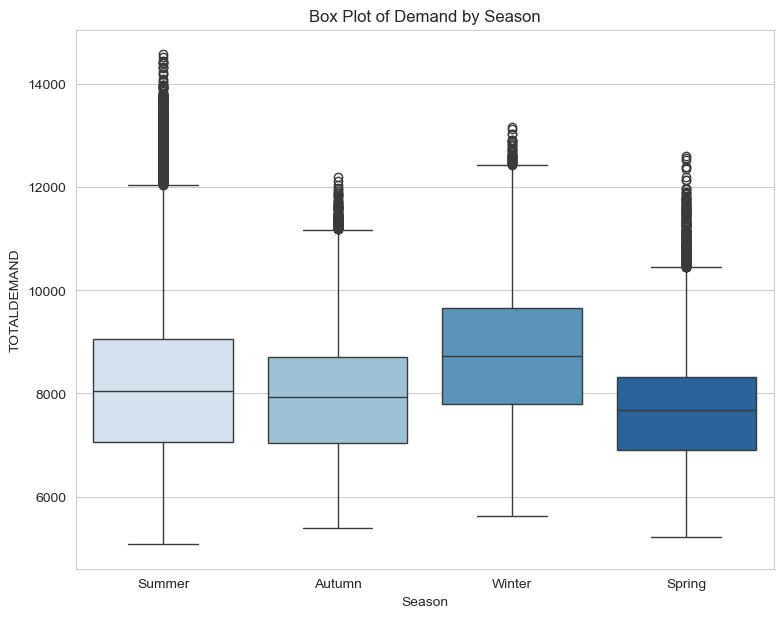

In [46]:
colors = sns.color_palette("Blues", len(demandNSW_clean['Season'].unique()))

plt.figure(figsize=(9, 7))
g = sns.boxplot(x='Season', y='TOTALDEMAND', data=demandNSW_clean, palette=colors)
g.set(title='Box Plot of Demand by Season')

plt.show()


/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/2517650271.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(x='Season', y='TOTALDEMAND', data=demandNSW_clean, palette=custom_colors)


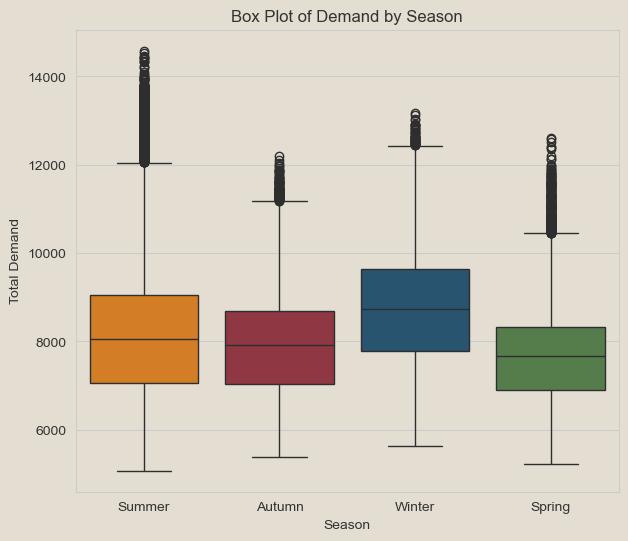

In [49]:
# Define the custom colors for each season
custom_colors = ['#f07f09', '#9e2837', '#1c577c', '#4e8543']

plt.figure(figsize=(7, 6))

# Update text and background colors
g = sns.boxplot(x='Season', y='TOTALDEMAND', data=demandNSW_clean, palette=custom_colors)
g.set(title='Box Plot of Demand by Season')

# Set the title, labels, and background colors
g.set_title('Box Plot of Demand by Season', color='#333332')
g.set_xlabel('Season', color='#333332')
g.set_ylabel('Total Demand', color='#333332')
g.set_facecolor('#e3ded1')

plt.xticks(color='#333332')
plt.yticks(color='#333332')
plt.gcf().patch.set_facecolor('#e3ded1')

plt.show()

Total demand varies among the seasons, the highest being Winter.

/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/1654629419.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(x='Hour', y='TOTALDEMAND', data=demandNSW_clean, palette=colors)


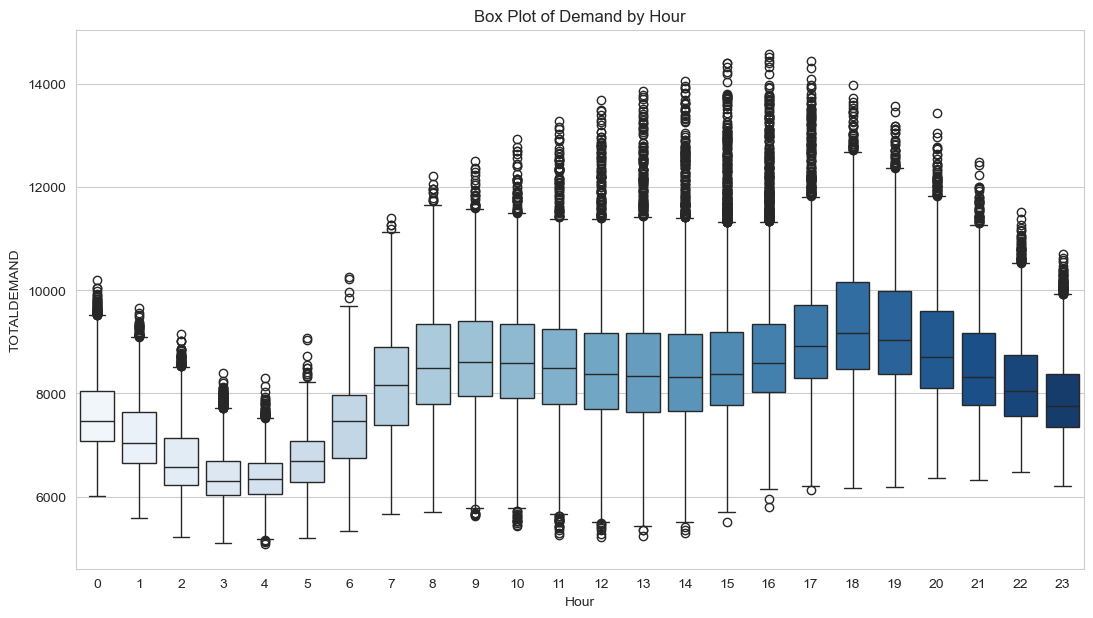

In [40]:
colors = sns.color_palette("Blues", len(demandNSW_clean['Hour'].unique()))

plt.figure(figsize=(13, 7))
g = sns.boxplot(x='Hour', y='TOTALDEMAND', data=demandNSW_clean, palette=colors)
g.set(title='Box Plot of Demand by Hour')

plt.show()

/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/43274818.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(x='Month', y='TOTALDEMAND', data=demandNSW_clean, palette=colors)
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_4160/43274818.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_labels)


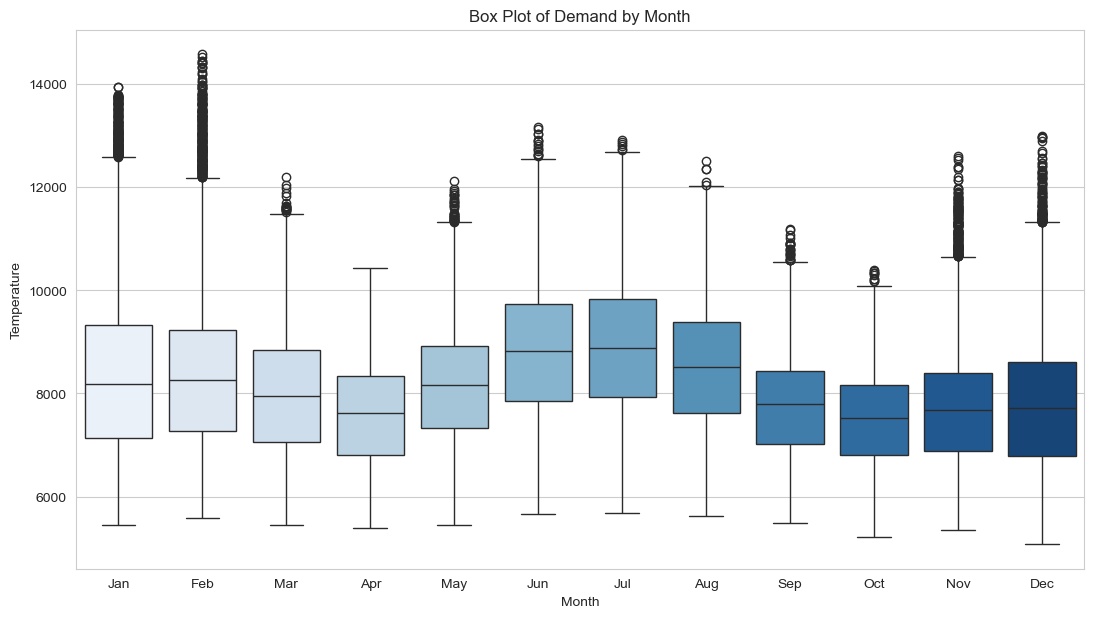

In [52]:
colors = sns.color_palette("Blues", len(demandNSW_clean['Month'].unique()))

# Define month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(13, 7))
g = sns.boxplot(x='Month', y='TOTALDEMAND', data=demandNSW_clean, palette=colors)
g.set(title='Box Plot of Demand by Month')

# Update the x-axis labels
g.set_xticklabels(month_labels)

plt.xlabel('Month')
plt.ylabel('Temperature')
plt.show()

In [35]:
print(demandNSW_clean)
demandNSW_clean.dtypes


                  DATETIME  TOTALDEMAND REGIONID  Holidays  Weekday  \
0      2010-01-01 00:00:00      8038.00     NSW1       1.0        4   
1      2010-01-01 00:30:00      7809.31     NSW1       1.0        4   
2      2010-01-01 01:00:00      7483.69     NSW1       1.0        4   
3      2010-01-01 01:30:00      7117.23     NSW1       1.0        4   
4      2010-01-01 02:00:00      6812.03     NSW1       1.0        4   
...                    ...          ...      ...       ...      ...   
196508 2021-03-17 22:00:00      7419.77     NSW1       0.0        2   
196509 2021-03-17 22:30:00      7417.91     NSW1       0.0        2   
196510 2021-03-17 23:00:00      7287.32     NSW1       0.0        2   
196511 2021-03-17 23:30:00      7172.39     NSW1       0.0        2   
196512 2021-03-18 00:00:00      7094.51     NSW1       0.0        3   

        Days/Holidays  Hour  Minute  Time  Month  Year  Season  
0                   7     0       0   0.0      1  2010  Summer  
1                

DATETIME         datetime64[ns]
TOTALDEMAND             float64
REGIONID                 object
Holidays                float64
Weekday                   int32
Days/Holidays             int64
Hour                      int32
Minute                    int32
Time                    float64
Month                     int32
Year                      int32
Season                   object
dtype: object

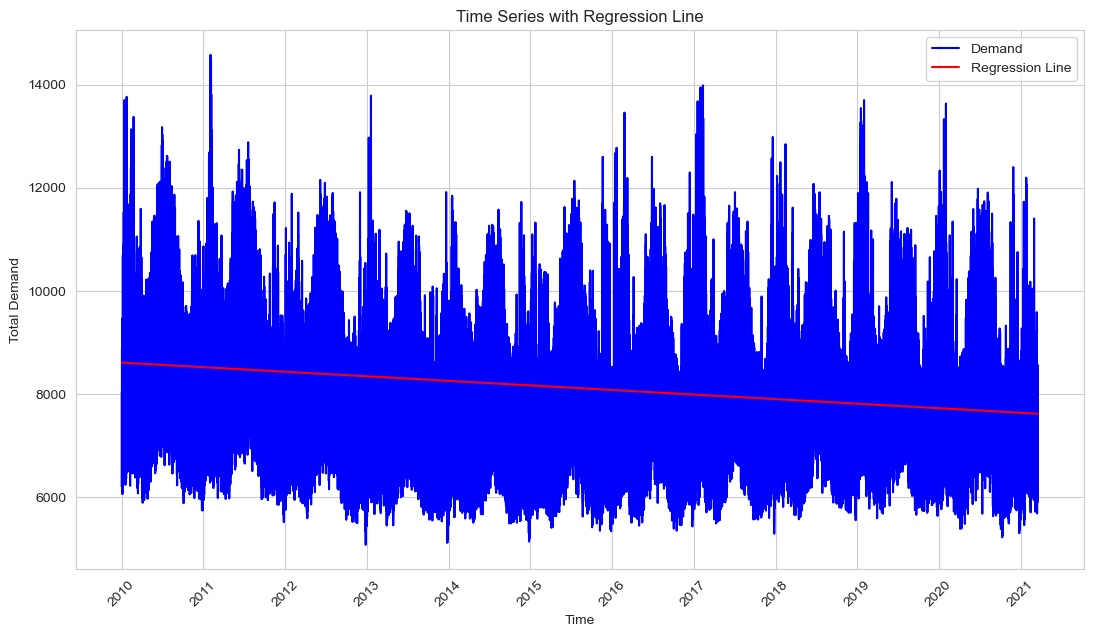

In [39]:
# time sereis of demand over time with a linear regression line

from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.dates as mdates

demandNSW_clean['DATETIME_numeric'] = pd.to_datetime(demandNSW_clean['DATETIME']).astype(np.int64) // 10**9

# Prepare the data for regression
X = demandNSW_clean['DATETIME_numeric'].values.reshape(-1, 1)
y = demandNSW_clean['TOTALDEMAND'].values

# Perform linear regression
regression = LinearRegression()
regression.fit(X, y)
y_pred = regression.predict(X)

# Create plot
plt.figure(figsize=(13, 7))
sns.lineplot(x=demandNSW_clean['DATETIME'], y=y, label='Demand', color='blue')
sns.lineplot(x=demandNSW_clean['DATETIME'], y=y_pred, label='Regression Line', color='red')
plt.title('Time Series with Regression Line')
plt.xlabel('Time')
plt.ylabel('Total Demand')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)
plt.show()

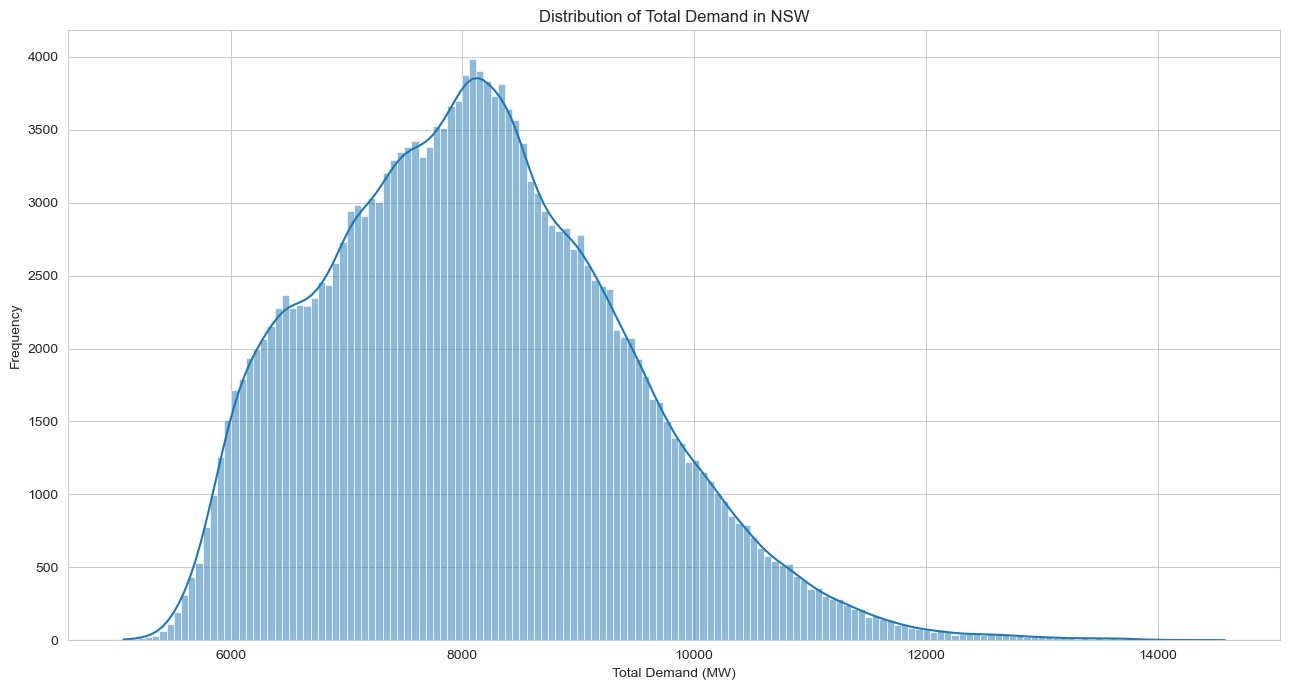

In [38]:
#histogram of total demand
plt.figure(figsize=(13, 7))
sns.histplot(demandNSW_clean['TOTALDEMAND'], kde=True) 
plt.title('Distribution of Total Demand in NSW') 
plt.xlabel('Total Demand (MW)') 
plt.ylabel('Frequency') 
plt.tight_layout() 
plt.show() 

Import in temperature dataset

In [61]:
tempNSW = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/temperature_nsw.csv")
tempNSW['DATETIME'] = pd.to_datetime(tempNSW['DATETIME'], format='%d/%m/%Y %H:%M')
print(tempNSW.shape)
print(tempNSW)
tempNSW_clean = tempNSW.dropna()
print(tempNSW_clean.shape)
print(tempNSW_clean.dtypes)

(220326, 3)
         LOCATION            DATETIME  TEMPERATURE
0       Bankstown 2010-01-01 00:00:00         23.1
1       Bankstown 2010-01-01 00:01:00         23.1
2       Bankstown 2010-01-01 00:30:00         22.9
3       Bankstown 2010-01-01 00:50:00         22.7
4       Bankstown 2010-01-01 01:00:00         22.6
...           ...                 ...          ...
220321  Bankstown 2021-03-17 23:00:00         19.1
220322  Bankstown 2021-03-17 23:20:00         19.0
220323  Bankstown 2021-03-17 23:30:00         18.8
220324  Bankstown 2021-03-17 23:34:00         18.8
220325  Bankstown 2021-03-18 00:00:00         18.6

[220326 rows x 3 columns]
(220326, 3)
LOCATION               object
DATETIME       datetime64[ns]
TEMPERATURE           float64
dtype: object


In [62]:
tempNSW_clean['DATETIME_ROUNDED'] = tempNSW_clean['DATETIME'].apply(round_to_nearest_half_hour)
tempNSW_clean = tempNSW_clean.drop_duplicates(subset=['DATETIME_ROUNDED'])
tempNSW_clean

,LOCATION,DATETIME,TEMPERATURE,DATETIME_ROUNDED
0,Bankstown,2010-01-01 00:00:00,23.1,2010-01-01 00:00:00
2,Bankstown,2010-01-01 00:30:00,22.9,2010-01-01 00:30:00
3,Bankstown,2010-01-01 00:50:00,22.7,2010-01-01 01:00:00
5,Bankstown,2010-01-01 01:30:00,22.5,2010-01-01 01:30:00
6,Bankstown,2010-01-01 02:00:00,22.5,2010-01-01 02:00:00
...,...,...,...,...
220319,Bankstown,2021-03-17 22:00:00,19.7,2021-03-17 22:00:00
220320,Bankstown,2021-03-17 22:30:00,19.5,2021-03-17 22:30:00
220321,Bankstown,2021-03-17 23:00:00,19.1,2021-03-17 23:00:00
220322,Bankstown,2021-03-17 23:20:00,19.0,2021-03-17 23:30:00


Merge with demand dataset

In [63]:
demand_temp_NSW1= pd.merge(demandNSW_clean, tempNSW_clean, 
                              how='left', left_on='DATETIME', right_on='DATETIME_ROUNDED')
demand_temp_NSW1['TEMPERATURE'] = demand_temp_NSW1['TEMPERATURE'].interpolate(method='linear', limit=4)
demand_temp_NSW1.isnull().sum()

DATETIME_x            0
TOTALDEMAND           0
REGIONID              0
Holidays              0
Weekday               0
Days/Holidays         0
Hour                  0
Minute                0
Time                  0
Month                 0
Year                  0
Season                0
DATETIME_numeric      0
LOCATION            564
DATETIME_y          564
TEMPERATURE         300
DATETIME_ROUNDED    564
dtype: int64

In [64]:
tempNSW_clean['Time_Difference'] = tempNSW_clean['DATETIME'] - tempNSW_clean['DATETIME'].shift(1)
print(tempNSW_clean.head())
print(tempNSW_clean.describe())
print(tempNSW_clean.shape)

    LOCATION            DATETIME  TEMPERATURE    DATETIME_ROUNDED  \
0  Bankstown 2010-01-01 00:00:00         23.1 2010-01-01 00:00:00   
2  Bankstown 2010-01-01 00:30:00         22.9 2010-01-01 00:30:00   
3  Bankstown 2010-01-01 00:50:00         22.7 2010-01-01 01:00:00   
5  Bankstown 2010-01-01 01:30:00         22.5 2010-01-01 01:30:00   
6  Bankstown 2010-01-01 02:00:00         22.5 2010-01-01 02:00:00   

  Time_Difference  
0             NaT  
2 0 days 00:30:00  
3 0 days 00:20:00  
5 0 days 00:40:00  
6 0 days 00:30:00  
                            DATETIME    TEMPERATURE  \
count                         195949  195949.000000   
mean   2015-08-12 07:05:39.653175040      17.532396   
min              2010-01-01 00:00:00      -1.300000   
25%              2012-10-23 22:00:00      13.500000   
50%              2015-08-10 15:30:00      17.900000   
75%              2018-06-01 09:00:00      21.500000   
max              2021-03-18 00:00:00      44.700000   
std                      

The max time between no logs in temprature is 3+ days, this difference is too large to interpolate. We could consider bringing in a different temperature dataset.

/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_2746/3845495468.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(x='Month', y='TEMPERATURE', data=demand_temp_NSW1, palette=colors)
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_2746/3845495468.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_labels)


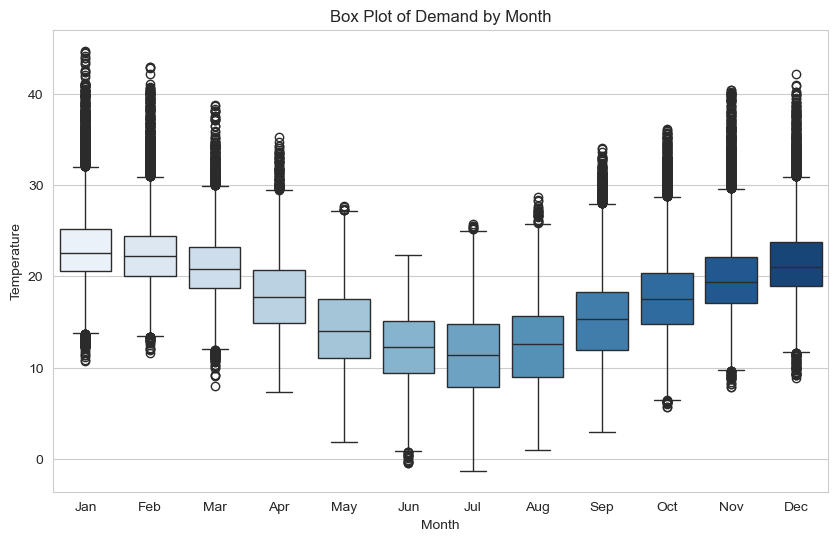

In [163]:
colors = sns.color_palette("Blues", len(demand_temp_NSW1['Month'].unique()))

# Define month labels
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 6))
g = sns.boxplot(x='Month', y='TEMPERATURE', data=demand_temp_NSW1, palette=colors)
g.set(title='Box Plot of Demand by Month')

# Update the x-axis labels
g.set_xticklabels(month_labels)

plt.xlabel('Month')
plt.ylabel('Temperature')
plt.show()

In [65]:
demand_temp_NSW= pd.merge(demandNSW_clean, tempNSW_clean, 
                              how='left', on='DATETIME')
demand_temp_NSW.drop(['REGIONID', 'LOCATION'], axis=1, inplace=True)
df_encoded = pd.get_dummies(demand_temp_NSW, columns=['Days/Holidays','Month','Season'], drop_first=True)
print(demand_temp_NSW)

                  DATETIME  TOTALDEMAND  Holidays  Weekday  Days/Holidays  \
0      2010-01-01 00:00:00      8038.00       1.0        4              7   
1      2010-01-01 00:30:00      7809.31       1.0        4              7   
2      2010-01-01 01:00:00      7483.69       1.0        4              7   
3      2010-01-01 01:30:00      7117.23       1.0        4              7   
4      2010-01-01 02:00:00      6812.03       1.0        4              7   
...                    ...          ...       ...      ...            ...   
196508 2021-03-17 22:00:00      7419.77       0.0        2              2   
196509 2021-03-17 22:30:00      7417.91       0.0        2              2   
196510 2021-03-17 23:00:00      7287.32       0.0        2              2   
196511 2021-03-17 23:30:00      7172.39       0.0        2              2   
196512 2021-03-18 00:00:00      7094.51       0.0        3              3   

        Hour  Minute  Time  Month  Year  Season  DATETIME_numeric  \
0     

In [65]:
print(demand_temp_NSW.isna().sum())
df_encoded = df_encoded.dropna()
df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce')
print(df_encoded.dtypes)

DATETIME                0
TOTALDEMAND             0
Holidays                0
Weekday                 0
Days/Holidays           0
Hour                    0
Minute                  0
Time                    0
Month                   0
Year                    0
Season                  0
TEMPERATURE         10792
DATETIME_ROUNDED    10792
Time_Difference     10793
dtype: int64
DATETIME              int64
TOTALDEMAND         float64
Holidays            float64
Weekday               int32
Hour                  int32
Minute                int32
Time                float64
Year                  int32
TEMPERATURE         float64
DATETIME_ROUNDED      int64
Time_Difference       int64
Days/Holidays_1        bool
Days/Holidays_2        bool
Days/Holidays_3        bool
Days/Holidays_4        bool
Days/Holidays_5        bool
Days/Holidays_6        bool
Days/Holidays_7        bool
Month_2                bool
Month_3                bool
Month_4                bool
Month_5                bool
Month_6

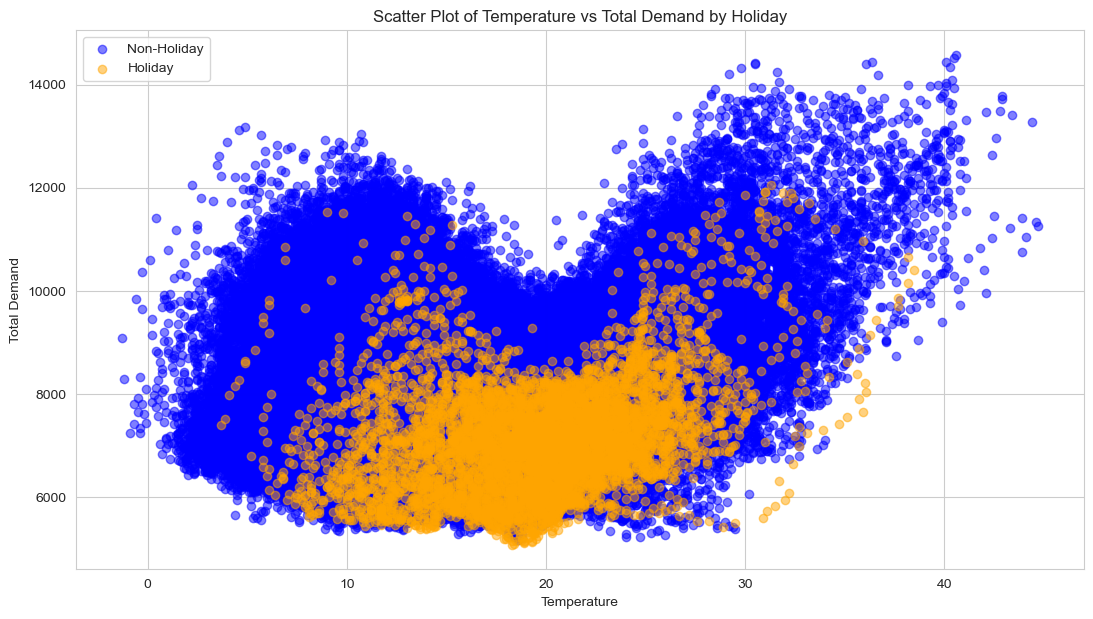

In [69]:
plt.figure(figsize=(13, 7))

# Scatter plot for Holiday == 0
holiday_0 = demand_temp_NSW[demand_temp_NSW['Holidays'] == 0]
plt.scatter(holiday_0['TEMPERATURE'], holiday_0['TOTALDEMAND'], color='blue', alpha=0.5, label='Non-Holiday')

# Scatter plot for Holiday == 1
holiday_1 = demand_temp_NSW[demand_temp_NSW['Holidays'] == 1]
plt.scatter(holiday_1['TEMPERATURE'], holiday_1['TOTALDEMAND'], color='orange', alpha=0.5, label='Holiday')

# Plot customization
plt.title('Scatter Plot of Temperature vs Total Demand by Holiday')
plt.xlabel('Temperature')
plt.ylabel('Total Demand')
plt.legend()
plt.show()

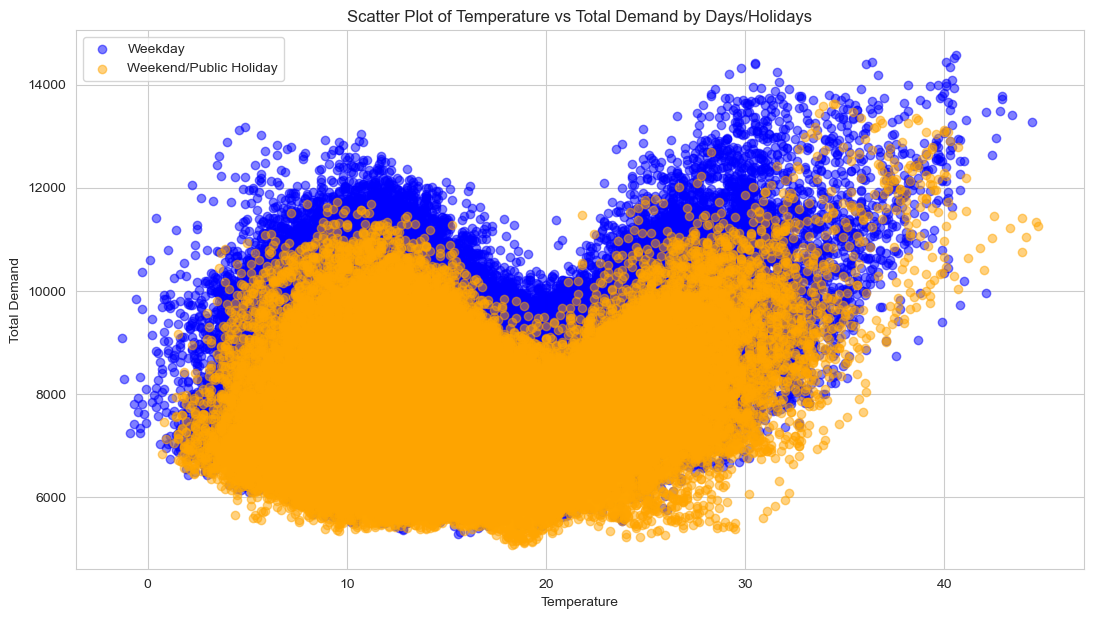

In [73]:
plt.figure(figsize=(13, 7))

# Scatter plot for Days/Holidays between 0-4
days_0_4 = demand_temp_NSW[(demand_temp_NSW['Days/Holidays'] >= 0) & (demand_temp_NSW['Days/Holidays'] <= 4)]
plt.scatter(days_0_4['TEMPERATURE'], days_0_4['TOTALDEMAND'], color='blue', alpha=0.5, label='Weekday')

# Scatter plot for Days/Holidays between 5-7
days_5_7 = demand_temp_NSW[(demand_temp_NSW['Days/Holidays'] >= 5) & (demand_temp_NSW['Days/Holidays'] <= 7)]
plt.scatter(days_5_7['TEMPERATURE'], days_5_7['TOTALDEMAND'], color='orange', alpha=0.5, label='Weekend/Public Holiday')

# Plot customization
plt.title('Scatter Plot of Temperature vs Total Demand by Days/Holidays')
plt.xlabel('Temperature')
plt.ylabel('Total Demand')
plt.legend()
plt.show()

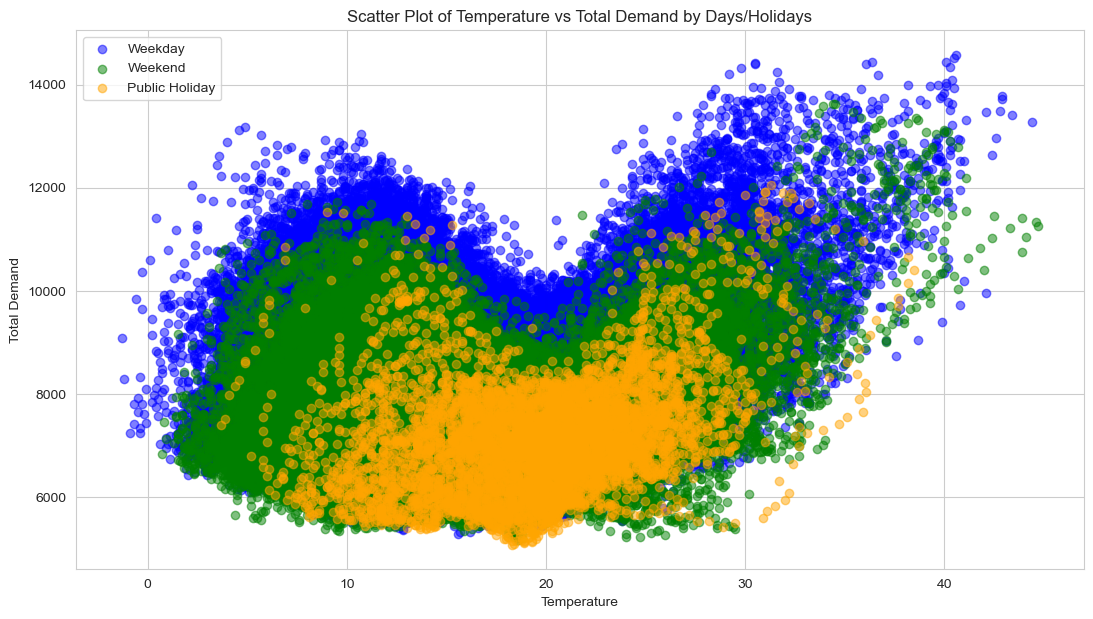

In [75]:
plt.figure(figsize=(13, 7))

# Scatter plot for Days/Holidays between 0-4 weekdays
days_0_4 = demand_temp_NSW[(demand_temp_NSW['Days/Holidays'] >= 0) & (demand_temp_NSW['Days/Holidays'] <= 4)]
plt.scatter(days_0_4['TEMPERATURE'], days_0_4['TOTALDEMAND'], color='blue', alpha=0.5, label='Weekday')

# Scatter plot for Days/Holidays between 5-6 weekends 
days_5_6 = demand_temp_NSW[(demand_temp_NSW['Days/Holidays'] >= 5) & (demand_temp_NSW['Days/Holidays'] <= 6)]
plt.scatter(days_5_6['TEMPERATURE'], days_5_6['TOTALDEMAND'], color='green', alpha=0.5, label='Weekend')

# Scatter plot for Days/Holidays equal to 7 public holidays
days_7 = demand_temp_NSW[demand_temp_NSW['Days/Holidays'] == 7]
plt.scatter(days_7['TEMPERATURE'], days_7['TOTALDEMAND'], color='orange', alpha=0.5, label='Public Holiday')

# Plot customization
plt.title('Scatter Plot of Temperature vs Total Demand by Days/Holidays')
plt.xlabel('Temperature')
plt.ylabel('Total Demand')
plt.legend()
plt.show()

Add humidity and solar data sourced from air quality nsw

In [46]:
def process_datetime(df, date_col, time_col):
    # Step 1: Create a new 'DATETIME' column by combining 'Date' and 'Time'
    df['DATETIME'] = df.apply(lambda x: f"{x[date_col]} {x[time_col]}", axis=1)

    # Step 2: Drop the original 'Date' and 'Time' columns
    df.drop([date_col, time_col], axis=1, inplace=True)

    # Step 3: Handle rows with '24:00' in the 'Time' part of the 'DATETIME' column
    mask = df['DATETIME'].str.contains(' 24:00')
    df.loc[mask, 'DATETIME'] = df.loc[mask, 'DATETIME'].str.replace(' 24:00', ' 00:00')
    df.loc[mask, 'DATETIME'] = pd.to_datetime(df.loc[mask, 'DATETIME'], format='%d/%m/%Y %H:%M') + pd.Timedelta(days=1)

    # Step 4: Convert the 'DATETIME' column to datetime format
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='%d/%m/%Y %H:%M', dayfirst=True)

    # Step 5: Drop duplicate rows based on the 'DATETIME' column
    df = df.drop_duplicates(subset=['DATETIME'])

    return df

In [47]:
def load_and_process_humidity_solar(file_paths, date_col='Date', time_col='Time'):
    # Load all CSV files and concatenate them into one DataFrame
    dataframes = [pd.read_csv(file_path) for file_path in file_paths]
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    # Process the Date and Time columns to create a DATETIME column
    combined_df['DATETIME'] = pd.to_datetime(combined_df[date_col] + ' ' + combined_df[time_col])
    
    return combined_df

In [48]:
humiditysolar1 = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/humiditysolar1.csv")
humiditysolar2 = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/humiditysolar2.csv")
humiditysolar = pd.concat([humiditysolar1, humiditysolar2], ignore_index=True)
humiditysolar = process_datetime(humiditysolar, 'Date', 'Time')
humiditysolar = humiditysolar.rename(columns={'CHULLORA HUMID 1h average [%]': 'Humidity', 'CHULLORA SOLAR 1h average [W/m≤]': 'SolarRadiation'})
humiditysolar.dropna(inplace=True)
humiditysolar['Time_Difference'] = humiditysolar['DATETIME'] - humiditysolar['DATETIME'].shift(1)

print(humiditysolar1)
print(humiditysolar.shape)
print(humiditysolar)
print(humiditysolar.dtypes)
print(humiditysolar.describe())

             Date   Time  CHULLORA HUMID 1h average [%]  \
0      31/12/2009  01:00                           86.7   
1      31/12/2009  02:00                           81.9   
2      31/12/2009  03:00                           84.6   
3      31/12/2009  04:00                           85.2   
4      31/12/2009  05:00                           83.3   
...           ...    ...                            ...   
49147  09/08/2015  20:00                           80.1   
49148  09/08/2015  21:00                           83.8   
49149  09/08/2015  22:00                           85.0   
49150  09/08/2015  23:00                           78.1   
49151  09/08/2015  24:00                           84.6   

       CHULLORA SOLAR 1h average [W/m≤]  
0                                  -2.5  
1                                  -2.8  
2                                  -2.1  
3                                  -1.0  
4                                   0.4  
...                                 ...

In [71]:
demand_temp_solar_NSW= pd.merge(demand_temp_NSW, humiditysolar, 
                              how='left', on='DATETIME')
print(demand_temp_solar_NSW)
demand_temp_solar_NSW.isnull().sum()

                  DATETIME  TOTALDEMAND  Holidays  Weekday  Days/Holidays  \
0      2010-01-01 00:00:00      8038.00       1.0        4              7   
1      2010-01-01 00:30:00      7809.31       1.0        4              7   
2      2010-01-01 01:00:00      7483.69       1.0        4              7   
3      2010-01-01 01:30:00      7117.23       1.0        4              7   
4      2010-01-01 02:00:00      6812.03       1.0        4              7   
...                    ...          ...       ...      ...            ...   
196521 2021-03-17 22:00:00      7419.77       0.0        2              2   
196522 2021-03-17 22:30:00      7417.91       0.0        2              2   
196523 2021-03-17 23:00:00      7287.32       0.0        2              2   
196524 2021-03-17 23:30:00      7172.39       0.0        2              2   
196525 2021-03-18 00:00:00      7094.51       0.0        3              3   

        Hour  Minute  Time  Month  Year  Season  TEMPERATURE  \
0          

DATETIME                 0
TOTALDEMAND              0
Holidays                 0
Weekday                  0
Days/Holidays            0
Hour                     0
Minute                   0
Time                     0
Month                    0
Year                     0
Season                   0
TEMPERATURE            579
Time_Difference_x      580
Humidity             99604
SolarRadiation       99604
Time_Difference_y    99604
dtype: int64

Interpolate missing values 

In [72]:
demand_temp_solar_NSW['TEMPERATURE'] = demand_temp_solar_NSW['TEMPERATURE'].interpolate(method='linear', limit=4)
demand_temp_solar_NSW['Humidity'] = demand_temp_solar_NSW['Humidity'].interpolate(method='linear', limit=4)
demand_temp_solar_NSW['SolarRadiation'] = demand_temp_solar_NSW['SolarRadiation'].interpolate(method='linear', inplace=True, limit=4)
demand_temp_solar_NSW.drop(['Holidays','Weekday','Hour','Minute','Time_Difference_x', 'Time_Difference_y'], axis=1, inplace=True)
demand_temp_solar_NSW.isnull().sum()


/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_1287/4085858472.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  demand_temp_solar_NSW['SolarRadiation'] = demand_temp_solar_NSW['SolarRadiation'].interpolate(method='linear', inplace=True, limit=4)


DATETIME               0
TOTALDEMAND            0
Days/Holidays          0
Time                   0
Month                  0
Year                   0
Season                 0
TEMPERATURE          301
Humidity            2376
SolarRadiation    196526
dtype: int64

In [51]:
demand_temp_solar_NSW.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196526 entries, 0 to 196525
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATETIME        196526 non-null  datetime64[ns]
 1   TOTALDEMAND     196526 non-null  float64       
 2   Days/Holidays   196526 non-null  int64         
 3   Time            196526 non-null  float64       
 4   Month           196526 non-null  int32         
 5   Year            196526 non-null  int32         
 6   Season          196526 non-null  object        
 7   TEMPERATURE     196225 non-null  float64       
 8   Humidity        194150 non-null  float64       
 9   SolarRadiation  194150 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int32(2), int64(1), object(1)
memory usage: 13.5+ MB


In [52]:
# creating categorical columns for linear regression 
cat_cols = ['Days/Holidays', 'Month', 'Year', 'Season']

for col in cat_cols:
    demand_temp_solar_NSW[col] = demand_temp_solar_NSW[col].astype('category')

demand_temp_solar_NSW.rename(columns={'Days/Holidays': 'Days_Holidays'}, inplace=True)
demand_temp_solar_NSW.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196526 entries, 0 to 196525
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATETIME        196526 non-null  datetime64[ns]
 1   TOTALDEMAND     196526 non-null  float64       
 2   Days_Holidays   196526 non-null  category      
 3   Time            196526 non-null  float64       
 4   Month           196526 non-null  category      
 5   Year            196526 non-null  category      
 6   Season          196526 non-null  category      
 7   TEMPERATURE     196225 non-null  float64       
 8   Humidity        194150 non-null  float64       
 9   SolarRadiation  194150 non-null  float64       
dtypes: category(4), datetime64[ns](1), float64(5)
memory usage: 9.7 MB


In [53]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
m = ols('TOTALDEMAND ~  C(Time) + C(Days_Holidays) + C(Month) + C(Year) + C(Season) + TEMPERATURE + Humidity + SolarRadiation', demand_temp_solar_NSW).fit()

print(m.summary())

                            OLS Regression Results                            
Dep. Variable:            TOTALDEMAND   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     6458.
Date:                Sat, 21 Sep 2024   Prob (F-statistic):               0.00
Time:                        10:21:01   Log-Likelihood:            -1.5399e+06
No. Observations:              193849   AIC:                         3.080e+06
Df Residuals:                  193769   BIC:                         3.081e+06
Df Model:                          79                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              6645.61

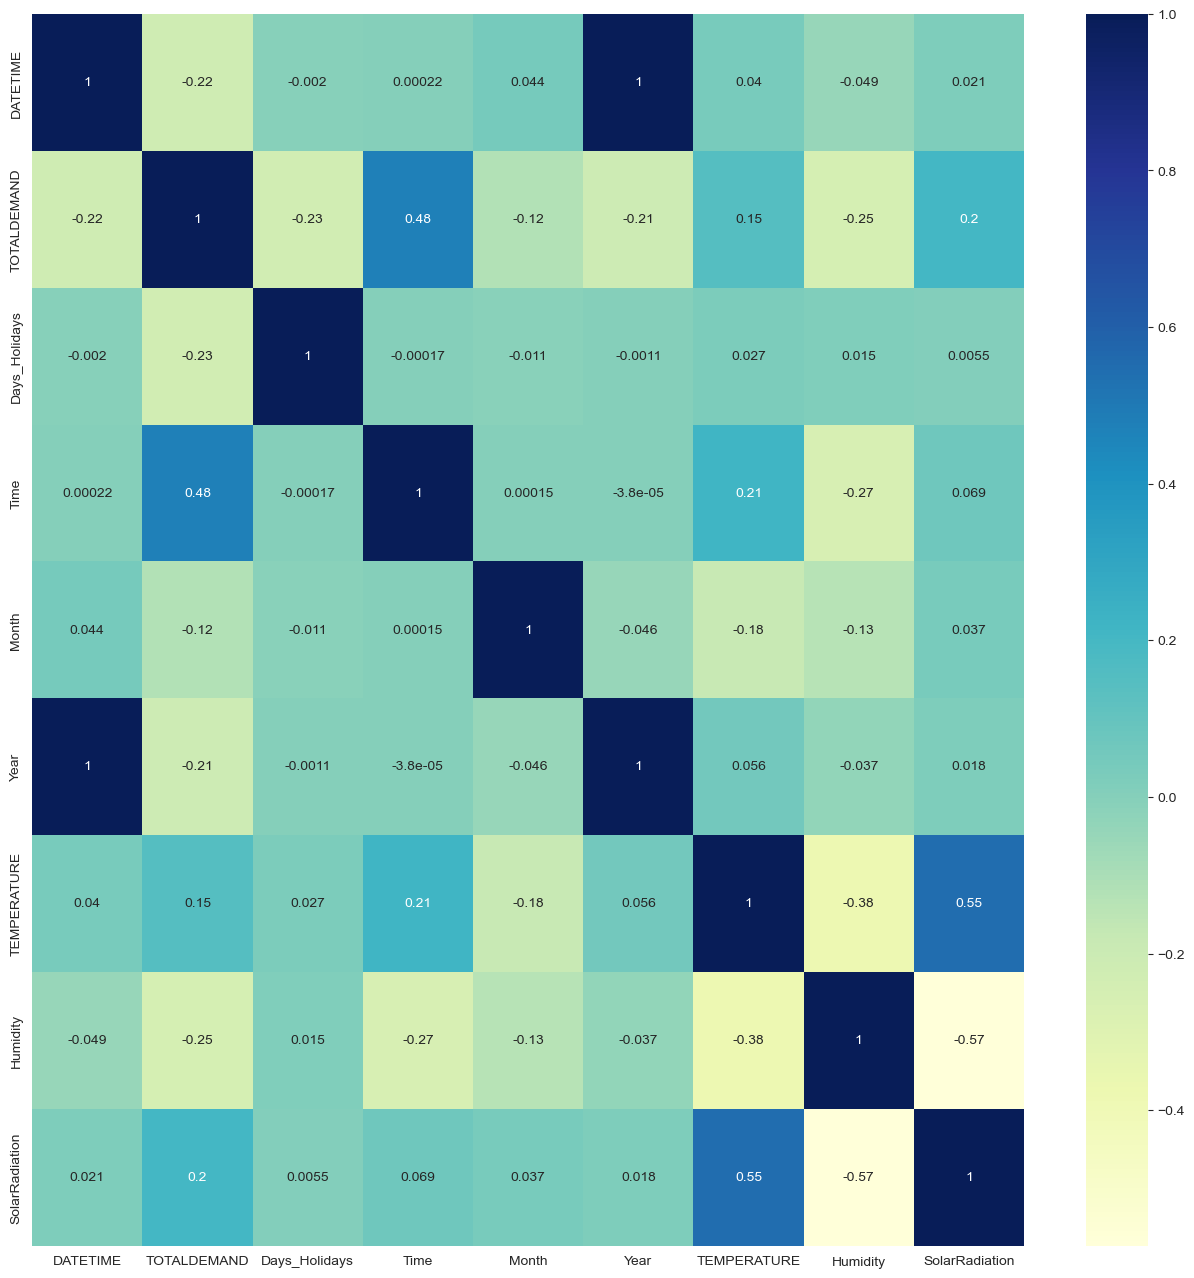

In [54]:
corr_heatmap = sns.heatmap(demand_temp_solar_NSW.drop('Season', axis=1).corr(method='pearson'), cmap="YlGnBu", annot=True)

In [55]:
def process_datetime(df, date_col, time_col):
    df['DATETIME'] = df.apply(lambda x: f"{x[date_col]} {x[time_col]}", axis=1)
    df.drop([date_col, time_col], axis=1, inplace=True)
    mask = df['DATETIME'].str.contains(' 24:00')
    df.loc[mask, 'DATETIME'] = df.loc[mask, 'DATETIME'].str.replace(' 24:00', ' 00:00')
    df.loc[mask, 'DATETIME'] = pd.to_datetime(df.loc[mask, 'DATETIME'], format='%d/%m/%Y %H:%M', dayfirst=True) + pd.Timedelta(days=1)
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='%d/%m/%Y %H:%M', dayfirst=True)
    df = df.drop_duplicates(subset=['DATETIME'])
    df = df.dropna()

    return df

def load_and_process_temp(file_paths, first_column_name, date_col='Date', time_col='Time'):
    dataframes = [pd.read_csv(file_path) for file_path in file_paths]
    combined_df = pd.concat(dataframes, ignore_index=True)
    combined_df = process_datetime(combined_df, date_col, time_col)
    combined_df.rename(columns={combined_df.columns[0]: first_column_name}, inplace=True)
    combined_df['Time_Difference'] = combined_df['DATETIME'] - combined_df['DATETIME'].shift(1)
    return combined_df

In [56]:
alburytemp = [
    "/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/alburytemp.csv",
    "/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/alburytemp2.csv"
]
alburytemp = load_and_process_temp(alburytemp, first_column_name='AlburyTemp')

bathursttemp = [
    "/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/bathursttemp.csv",
    "/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/bathursttemp2.csv"
]
bathursttemp = load_and_process_temp(bathursttemp, first_column_name='BathurstTemp')

tamworthtemp = [
    "/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/tamworthtemp.csv",
    "/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/tamworthtemp2.csv"
]
tamworthtemp = load_and_process_temp(tamworthtemp, first_column_name='TamworthTemp')



In [67]:
demand_temp_solar_NSWa= pd.merge(demand_temp_solar_NSW, alburytemp, 
                              how='left', on='DATETIME')
demand_temp_solar_NSWab= pd.merge(demand_temp_solar_NSWa, bathursttemp, 
                              how='left', on='DATETIME')
demand_temp_solar_NSWabt= pd.merge(demand_temp_solar_NSWab, tamworthtemp, 
                              how='left', on='DATETIME')
demand_temp_solar_NSWabt.drop(['Time_Difference', 'Time_Difference_x','Time_Difference_y'], axis=1, inplace=True)
demand_temp_solar_NSWabt['AlburyTemp'] = demand_temp_solar_NSWabt['AlburyTemp'].interpolate(method='linear', limit=4)
demand_temp_solar_NSWabt['BathurstTemp'] = demand_temp_solar_NSWabt['BathurstTemp'].interpolate(method='linear', limit=4)
demand_temp_solar_NSWabt['TamworthTemp'] = demand_temp_solar_NSWabt['TamworthTemp'].interpolate(method='linear', limit=4)


In [69]:
demand_temp_solar_NSWabt.isnull().sum()

DATETIME             0
TOTALDEMAND          0
Days_Holidays        0
Time                 0
Month                0
Year                 0
Season               0
TEMPERATURE        301
Humidity          2376
SolarRadiation    2376
AlburyTemp        2672
BathurstTemp      1976
TamworthTemp       760
dtype: int64

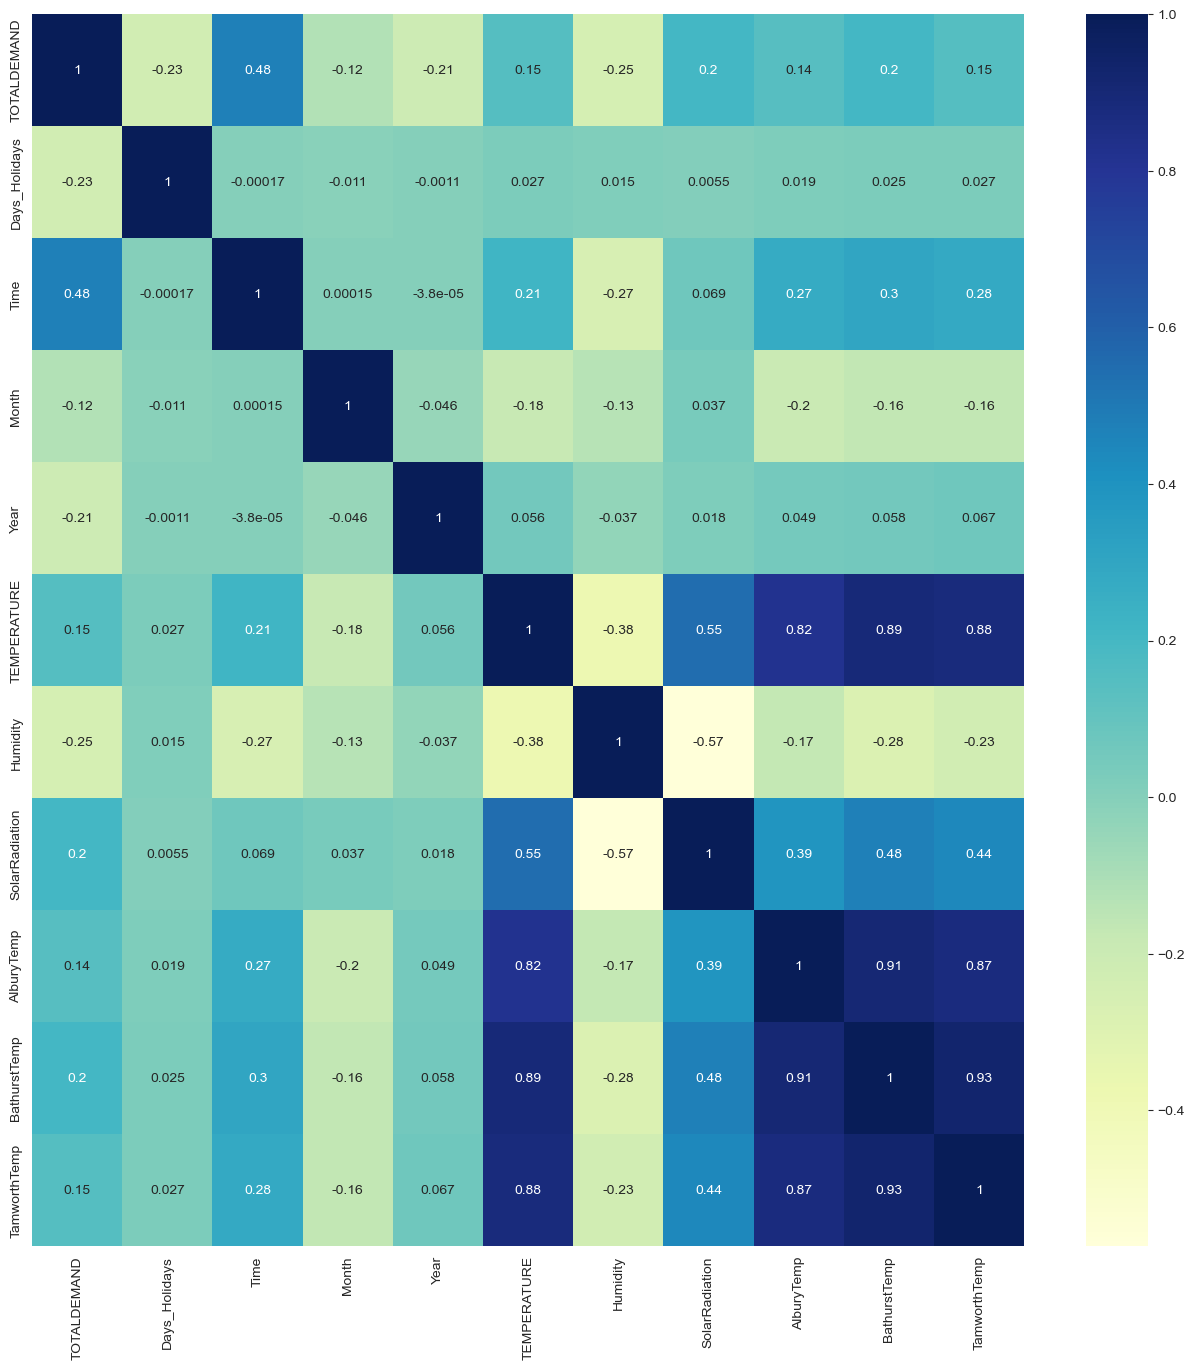

In [68]:
corr_heatmap = sns.heatmap(demand_temp_solar_NSWabt.drop(['DATETIME','Season'], axis=1).corr(method='pearson'), cmap="YlGnBu", annot=True)

### Produce heatmap used in LSTM

In [95]:
demandNSW = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/totaldemand_nsw.csv",
                 index_col=[0],
                 parse_dates=[0],
                 date_format = '%d/%m/%Y %H:%M')
tempNSW = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/temperature_nsw.csv")
tempNSW['DATETIME'] = pd.to_datetime(tempNSW['DATETIME'], format='%d/%m/%Y %H:%M')
tempNSW.drop(['LOCATION'], axis=1, inplace=True)
df= pd.merge(demandNSW, tempNSW, 
                              how='left', left_on='DATETIME', right_on='DATETIME')
df.drop(['REGIONID'], axis=1, inplace=True)
# Created copy
df2 = df.copy()
nsw_holidays = holidays.Australia(state='NSW', years=range(2010, 2022))

# Display the NSW holidays for the specified years
for date, name in sorted(nsw_holidays.items()):
    print(f"{date}: {name}")
    
df2['Holidays'] = df2.DATETIME.apply(lambda date: nsw_holidays.get(date))
df2.holidays = df2.Holidays.fillna(0) 
# df2.Holidays.unique()
mapping = {"New Year's Day" : 1,
           'None' : 0,
           'NaN' : 0,
           'Australia Day' : 1,
           'Good Friday' : 1,
           'Easter Saturday' : 1,
           'Easter Monday' : 1,
           'ANZAC Day' : 1,
           'ANZAC Day (observed)' : 1,
           "Queen's Birthday" : 1,
           'Labour Day' : 1,
           'Christmas Day' : 1,
           'Boxing Day' : 1,
           'Boxing Day (observed)' : 1 ,
           "New Year's Day (observed)" : 1,
           'Easter Sunday' : 1, 
           'ANZAC Day; Easter Monday' : 1,
           'Christmas Day (observed)' : 1,
           'Bank Holiday' : 0
          }

df2 = df2.replace({'Holidays': mapping})

df2['Holidays'].fillna(0, inplace=True)
# df2.Holidays.unique()
df2['DATETIME'] = pd.to_datetime(df2['DATETIME'])
df2['Weekday'] = df2['DATETIME'].dt.dayofweek
df2['Days_Holidays'] = df2.apply(
    lambda row: 7 if row['Holidays'] == 1 else row['Weekday'], axis=1
)
df2.drop(['Holidays','Weekday'], axis=1, inplace=True)
df2['Hour'] = df2.DATETIME.dt.hour
df2['Minute'] = df2.DATETIME.dt.minute
df2['Time'] = (df2.Hour * 60 + df2.Minute) / 60
df2['Month'] = df2.DATETIME.dt.month
df2['Year'] = df2.DATETIME.dt.year
df2['TotalDemand_1S'] = df2['TOTALDEMAND'].shift(1)
df2['TotalDemand_Second_2S'] = df2['TOTALDEMAND'].shift(2)
df2['Time_sin'] = np.sin(2 * np.pi * df2['Time'] / 48)
df2['Time_cos'] = np.cos(2 * np.pi * df2['Time'] / 48)

print(df2)

2010-01-01: New Year's Day
2010-01-26: Australia Day
2010-04-02: Good Friday
2010-04-03: Easter Saturday
2010-04-05: Easter Monday
2010-04-25: ANZAC Day
2010-04-26: ANZAC Day (observed)
2010-06-14: Queen's Birthday
2010-08-02: Bank Holiday
2010-10-04: Labour Day
2010-12-25: Christmas Day
2010-12-26: Boxing Day
2010-12-27: Boxing Day (observed)
2011-01-01: New Year's Day
2011-01-03: New Year's Day (observed)
2011-01-26: Australia Day
2011-04-22: Good Friday
2011-04-23: Easter Saturday
2011-04-24: Easter Sunday
2011-04-25: ANZAC Day; Easter Monday
2011-06-13: Queen's Birthday
2011-10-03: Labour Day
2011-12-25: Christmas Day
2011-12-26: Boxing Day
2011-12-27: Christmas Day (observed)
2012-01-01: New Year's Day
2012-01-02: New Year's Day (observed)
2012-01-26: Australia Day
2012-04-06: Good Friday
2012-04-07: Easter Saturday
2012-04-08: Easter Sunday
2012-04-09: Easter Monday
2012-04-25: ANZAC Day
2012-06-11: Queen's Birthday
2012-10-01: Labour Day
2012-12-25: Christmas Day
2012-12-26: Box

/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_2746/3896397874.py:20: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df2.holidays = df2.Holidays.fillna(0)
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_2746/3896397874.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2 = df2.replace({'Holidays': mapping})
/var/folders/8c/m0knxzv12yz2gbqt69ht9jp40000gn/T/ipykernel_2746/3896397874.py:45: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate o

                  DATETIME  TOTALDEMAND  TEMPERATURE  Days_Holidays  Hour  \
0      2010-01-01 00:00:00      8038.00         23.1              7     0   
1      2010-01-01 00:30:00      7809.31         22.9              7     0   
2      2010-01-01 01:00:00      7483.69         22.6              7     1   
3      2010-01-01 01:30:00      7117.23         22.5              7     1   
4      2010-01-01 02:00:00      6812.03         22.5              7     2   
...                    ...          ...          ...            ...   ...   
196521 2021-03-17 22:00:00      7419.77         19.7              2    22   
196522 2021-03-17 22:30:00      7417.91         19.5              2    22   
196523 2021-03-17 23:00:00      7287.32         19.1              2    23   
196524 2021-03-17 23:30:00      7172.39         18.8              2    23   
196525 2021-03-18 00:00:00      7094.51         18.6              3     0   

        Minute  Time  Month  Year  TotalDemand_1S  TotalDemand_Second_2S  \

In [98]:
def process_datetime(df, date_col, time_col):
    # Step 1: Create a new 'DATETIME' column by combining 'Date' and 'Time'
    df['DATETIME'] = df.apply(lambda x: f"{x[date_col]} {x[time_col]}", axis=1)

    # Step 2: Drop the original 'Date' and 'Time' columns
    df.drop([date_col, time_col], axis=1, inplace=True)

    # Step 3: Handle rows with '24:00' in the 'Time' part of the 'DATETIME' column
    mask = df['DATETIME'].str.contains(' 24:00')
    df.loc[mask, 'DATETIME'] = df.loc[mask, 'DATETIME'].str.replace(' 24:00', ' 00:00')
    df.loc[mask, 'DATETIME'] = pd.to_datetime(df.loc[mask, 'DATETIME'], format='%d/%m/%Y %H:%M') + pd.Timedelta(days=1)

    # Step 4: Convert the 'DATETIME' column to datetime format
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='%d/%m/%Y %H:%M', dayfirst=True)

    # Step 5: Drop duplicate rows based on the 'DATETIME' column
    df = df.drop_duplicates(subset=['DATETIME'])

    return df

def load_and_process_humidity_solar(file_paths, date_col='Date', time_col='Time'):
    # Load all CSV files and concatenate them into one DataFrame
    dataframes = [pd.read_csv(file_path) for file_path in file_paths]
    combined_df = pd.concat(dataframes, ignore_index=True)
    
    # Process the Date and Time columns to create a DATETIME column
    combined_df['DATETIME'] = pd.to_datetime(combined_df[date_col] + ' ' + combined_df[time_col])
    
    return combined_df

humiditysolar1 = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/humiditysolar1.csv")
humiditysolar2 = pd.read_csv("/Users/benjamintrojko/Library/CloudStorage/Dropbox/University/24H5 ZZSC9020 Data Science Project/data/NSW/humiditysolar2.csv")
humiditysolar = pd.concat([humiditysolar1, humiditysolar2], ignore_index=True)
humiditysolar = process_datetime(humiditysolar, 'Date', 'Time')
humiditysolar = humiditysolar.rename(columns={'CHULLORA HUMID 1h average [%]': 'Humidity', 'CHULLORA SOLAR 1h average [W/m≤]': 'SolarRadiation'})
humiditysolar.dropna(inplace=True)

df3= pd.merge(df2, humiditysolar, 
                              how='left', on='DATETIME')
df3['Humidity'] = df3['Humidity'].interpolate(method='linear', limit=4)
df3['SolarRadiation'] = df3['SolarRadiation'].interpolate(method='linear', limit=4)

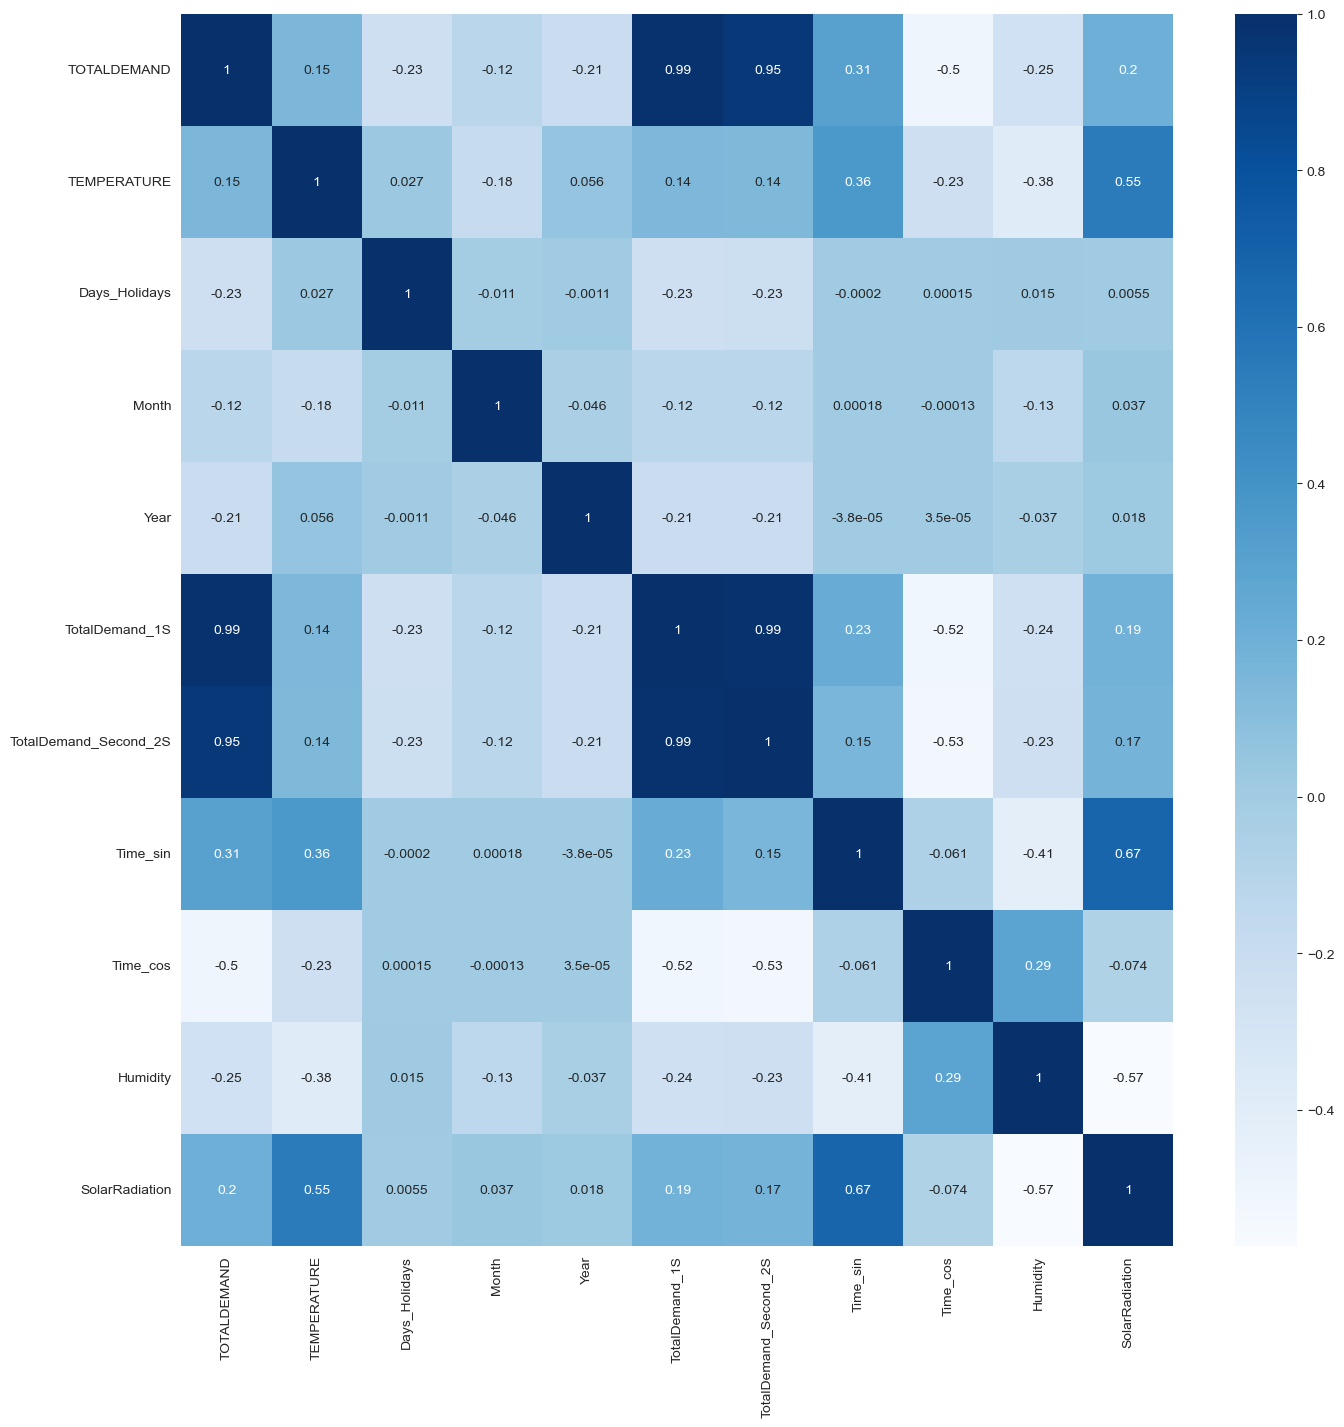

In [99]:
corr_heatmap = sns.heatmap(df3.drop(['DATETIME','Hour','Minute', 'Time'], axis=1).corr(method='pearson'), cmap="Blues", annot=True)